# Proyecto Final - Machine Learning
**Análisis y Clasificación de la Calidad de Aguas Superficiales mediante Ciencia de Datos y Aprendizaje Automático**

Autores: 
* Fanny Sandoval
* María José Espinal
* Enrique Segura

# Tabla de Contenidos

<a id='table_of_contents'></a>

0. [Importar librerías](#imports)
1. [Auditoría inicial de los datos](#initial_eda)

   1.1. [Dimensiones del dataset](#size_data)
   
   1.2. [Tipos de datos](#data_type)

   1.3. [Duplicados](#duplicated)

   1.4. [Valores faltantes](#missing)

   1.5 [Variable objetivo](#obj_variable)

   1.6 [Revisión de <](#rev_sym)

2. [Análisis profundo de los datos](#dive_deep)
   
   2.1. [Registros faltantes de la variable objetivo](#missing_obj_variable)

   2.2. [Revisión de duplicados](#duplicated_rev)

   2.3. [Variables ambientales](#env_variables)

3. [Limpieza de los datos](#data_cleaning)

   3.1. [Columnas vacías](#empty_columns)

   3.2. [Tratamiento de valores por debajo del límite de detección](#below_values)

4. [Preprocesamiento de los datos](#data_prep)

   4.1. [Clasificación de variables](#data_classification)

   4.2. [Selección inicial de variables predictoras](#variable_selection)

   4.3. [Creación del conjunto de datos de trabajo](#work_df)

5. [Estadística descriptiva de las variables ambientales](#descriptive_stats)
   
   5.1. [Interpretación de la estadística descriptiva](#stats_interpretation)
   
   5.2. [Detección de valores atípicos mediante IQR](#iqr)

   5.3. [Visualización de valores atípicos](#outliers_view)

   5.4. [Análisis de valores faltantes según la categoría del semáforo](#light_missing)

   5.5. [Selección de variables para el modelado](#model_variable)

6. [Imputación](#imputation)
7. [Transformación de sesgo y análisis de correlaciones](#corr_analysis)

   7.1. [Variables candidatas a transformación logarítmica](#log_transformation)

   7.2. [Comparación de sesgo](#skewness)

   7.3. [Matriz de correlación](#correlation)

   7.4. [Mapa de calor limpio](#heatmap)

8. [Preparación de variables para el modelado](#model_prep)

   8.1. [Comparación de métodos de escalamiento](#scaler)

9. [K-Means](#k_means)






# 0. Importar librerías <a id='imports'></a>
[Back to top](#table_of_contents)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



# 1. Auditoría inicial de los datos <a id='initial_eda'></a>
[Back to top](#table_of_contents)


Antes de realizar transformaciones o modelos de Machine Learning, se validará la estructura del dataset, tipos de datos, valores faltantes, duplicados y distribución de la variable objetivo. 
Esta etapa permite conocer la calidad de los datos y tomar decisiones de limpieza fundamentadas.

In [2]:
pd.set_option('display.max_columns', None)
file_path = r'C:\Users\ghass\Downloads\Datos_de_calidad_del_agua_de_sitios_de_monitoreo_de_aguas_superficiales_2020.csv'
df = pd.read_csv(file_path, encoding='latin1')

display(df.head(19))

,CLAVE,SITIO,ORGANISMO_DE_CUENCA,ESTADO,MUNICIPIO,CUENCA,CUERPO DE AGUA,TIPO,SUBTIPO,LONGITUD,LATITUD,PERIODO,DBO_mg/L,CALIDAD_DBO,DQO_mg/L,CALIDAD_DQO,SST_mg/L,CALIDAD_SST,COLI_FEC_NMP_100mL,CALIDAD_COLI_FEC,E_COLI_NMP_100mL,CALIDAD_E_COLI,ENTEROC_NMP_100mL,CALIDAD_ENTEROC,OD_PORC,CALIDAD_OD_PORC,OD_PORC_SUP,CALIDAD_OD_PORC_SUP,OD_PORC_MED,CALIDAD_OD_PORC_MED,OD_PORC_FON,CALIDAD_OD_PORC_FON,TOX_D_48_UT,CALIDAD_TOX_D_48,TOX_V_15_UT,CALIDAD_TOX_V_15,TOX_D_48_SUP_UT,CALIDAD TOX_D_48_SUP,TOX_D_48_FON_UT,CALIDAD_TOX_D_48_FON,TOX_FIS_SUP_15_UT,CALIDAD_TOX_FIS_SUP_15,TOX_FIS_FON_15_UT,CALIDAD_TOX_FIS_FON_15,SEMAFORO,CONTAMINANTES,CUMPLE_CON_DBO,CUMPLE_CON_DQO,CUMPLE_CON_SST,CUMPLE_CON_CF,CUMPLE_CON_E_COLI,CUMPLE_CON_ENTEROC,CUMPLE_CON_OD,CUMPLE_CON_TOX,GRUPO
0,DLAGU8,PRESA EL SAUCILLO 100M AGUAS ARRIBA DE LA CORTINA,LERMA SANTIAGO PACIFICO,AGUASCALIENTES,RINCON DE ROMOS,RIO SAN PEDRO,PRESA EL SAUCILLO,LENTICO,PRESA,-102.33911,22.24730,2020.0,6,Buena calidad,54.08,Contaminada,13.75,Excelente,1162,Contaminada,98,Excelente,NaN,NaN,NaN,NaN,46.8,Aceptable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,<1,No Toxico,NaN,NaN,Rojo,"DQO,CF,",SI,NO,SI,NO,SI,ND,SI,SI,LENTICO
1,DLBAJ100,"LOS CABOS SEG 22, 2 ISA10B",PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN JOSE DEL CABO,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-109.84290,22.90473,2020.0,NaN,NaN,NaN,NaN,<10,Excelente,NaN,NaN,NaN,NaN,20,Excelente,NaN,NaN,92,Excelente,95.4,Excelente,92.2,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
2,DLBAJ101,"LOS CABOS SEG 22, 1 ISA10B",PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-109.86442,22.89880,2020.0,NaN,NaN,NaN,NaN,<10,Excelente,NaN,NaN,NaN,NaN,<3,Excelente,NaN,NaN,92,Excelente,95.4,Excelente,92.2,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
3,DLBAJ102,LOS CABOS 3,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.88604,22.89609,2020.0,NaN,NaN,NaN,NaN,13.9667,Excelente,NaN,NaN,NaN,NaN,<3,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,86.7,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
4,DLBAJ103,LOS CABOS 1,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.89657,22.87694,2020.0,NaN,NaN,NaN,NaN,<10,Excelente,NaN,NaN,NaN,NaN,30,Excelente,NaN,NaN,96.2,Excelente,95.9,Excelente,95.5,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
5,DLBAJ104,BAHIA CABO SAN LUCAS,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.90250,22.88000,2020.0,NaN,NaN,NaN,NaN,22.0667,Excelente,NaN,NaN,NaN,NaN,<3,Excelente,NaN,NaN,90.1,Excelente,95.2,Excelente,94.2,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
6,DLBAJ105,LOS CABOS 2,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.90540,22.88310,2020.0,NaN,NaN,NaN,NaN,13.9667,Excelente,NaN,NaN,NaN,NaN,90,Excelente,NaN,NaN,81.9,Excelente,82.4,Excelente,79.2,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
7,DLBAJ106W2,LAGUNA TODOS SANTOS - CENTRO DE LA LAGUNA,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LA PAZ,TODOS SANTOS,TODOS SANTOS,COSTERO,LAGUNA,-110.23902,23.43930,2020.0,NaN,NaN,NaN,NaN,57.85,Buena calidad,NaN,NaN,NaN,NaN,402,Contaminada,NaN,NaN,NaN,NaN,NaN,NaN,146,Contaminada,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Rojo,"ENT_FEC,OD%F,",ND,ND,SI,ND,ND,NO,NO,SI,COSTERO
8,DLBAJ109,MANANTIAL SAN REGIS,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LA PAZ,TODOS SANTOS,TODOS SANTOS,LOTICO,ARROYO,-110.22379,23.45805,2020.0,<2,Excelente,<10,Excelente,33.9,Buena calidad,3873,Contaminada,512,Buena calidad

## 1.1. Dimensiones del dataset <a id='size_data'></a>
[Back to top](#table_of_contents)

In [3]:
print("Dimensiones del dataset:")
print(df.shape)

print("\nNúmero de filas:")
print(df.shape[0])

print("\nNúmero de columnas:")
print(df.shape[1])

Dimensiones del dataset:
(4141, 55)

Número de filas:
4141

Número de columnas:
55


## 1.2. Tipos de datos <a id='data_type'></a>
[Back to top](#table_of_contents)

In [4]:
df.dtypes.value_counts()

str        48
float64     7
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4141 entries, 0 to 4140
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CLAVE                   3493 non-null   str    
 1   SITIO                   3493 non-null   str    
 2   ORGANISMO_DE_CUENCA     3493 non-null   str    
 3   ESTADO                  3493 non-null   str    
 4   MUNICIPIO               3493 non-null   str    
 5   CUENCA                  3492 non-null   str    
 6   CUERPO DE AGUA          3479 non-null   str    
 7   TIPO                    3493 non-null   str    
 8   SUBTIPO                 3479 non-null   str    
 9   LONGITUD                3493 non-null   float64
 10  LATITUD                 3493 non-null   float64
 11  PERIODO                 3493 non-null   float64
 12  DBO_mg/L                2581 non-null   str    
 13  CALIDAD_DBO             2581 non-null   str    
 14  DQO_mg/L                2581 non-null   str    
 15

## 1.3. Duplicados <a id='duplicated'></a>
[Back to top](#table_of_contents)

In [6]:
duplicados = df.duplicated().sum()

print(f"Número de registros duplicados: {duplicados}")

Número de registros duplicados: 647


## 1.4. Valores faltantes <a id='missing'></a>
[Back to top](#table_of_contents)

In [7]:
faltantes = pd.DataFrame({
    "Valores faltantes": df.isnull().sum(),
    "Porcentaje": df.isnull().mean() * 100
})

faltantes = faltantes.sort_values(
    "Porcentaje",
    ascending=False
)

display(faltantes)

,Valores faltantes,Porcentaje
TOX_FIS_FON_15_UT,4141,100.000000
CALIDAD_TOX_FIS_FON_15,4141,100.000000
TOX_D_48_FON_UT,4141,100.000000
CALIDAD_TOX_D_48_FON,4141,100.000000
OD_PORC_MED,3654,88.239556
CALIDAD_OD_PORC_MED,3654,88.239556
CALIDAD TOX_D_48_SUP,3379,81.598648
TOX_D_48_SUP_UT,3379,81.598648
ENTEROC_NMP_100mL,3237,78.169524
CALIDAD_ENTEROC,3237,78.169524


## 1.5 Variable objetivo <a id='obj_variable'></a>
[Back to top](#table_of_contents)

**Balance de clases**

In [8]:
print("Distribución de SEMAFORO - cantidad:")

display(
    df["SEMAFORO"].value_counts()
)

Distribución de SEMAFORO - cantidad:


SEMAFORO
Verde       1267
Amarillo    1135
Rojo        1091
Name: count, dtype: int64

In [9]:
print("Distribución de SEMAFORO -  porcentaje:")

display(
    df["SEMAFORO"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

Distribución de SEMAFORO -  porcentaje:


SEMAFORO
Verde       36.27
Amarillo    32.49
Rojo        31.23
Name: proportion, dtype: float64

## 1.6 Revisión de < <a id='rev_sym'></a>
[Back to top](#table_of_contents)

In [10]:
for col in df.columns:
    cantidad = df[col].astype(str).str.contains(
        "<",
        regex=False,
        na=False
    ).sum()

    if cantidad > 0:
        print(f"{col}: {cantidad} valores con '<'")

DBO_mg/L: 1224 valores con '<'
DQO_mg/L: 559 valores con '<'
SST_mg/L: 880 valores con '<'
COLI_FEC_NMP_100mL: 109 valores con '<'
E_COLI_NMP_100mL: 365 valores con '<'
ENTEROC_NMP_100mL: 464 valores con '<'
OD_PORC: 110 valores con '<'
OD_PORC_SUP: 15 valores con '<'
OD_PORC_MED: 14 valores con '<'
OD_PORC_FON: 35 valores con '<'
TOX_D_48_UT: 1729 valores con '<'
TOX_V_15_UT: 1671 valores con '<'
TOX_D_48_SUP_UT: 738 valores con '<'
TOX_FIS_SUP_15_UT: 1657 valores con '<'


# 2. Análisis profundo de los datos <a id='#dive_deep'></a>
[Back to top](#table_of_contents)

## 2.1. Registros faltantes de la variable objetivo <a id='missing_obj_variable'></a>
[Back to top](#table_of_contents)

La variable `SEMAFORO` constituye la variable objetivo del modelo de clasificación. Por esta razón, los registros que no contienen una clasificación ambiental no pueden utilizarse para entrenar el modelo supervisado.

Antes de eliminarlos, se verificará si corresponden a registros completamente vacíos o estructuralmente incompletos.

In [11]:
filas_sin_semaforo = df[df["SEMAFORO"].isna()]

print("Filas sin SEMAFORO:", len(filas_sin_semaforo))

display(filas_sin_semaforo.head())

Filas sin SEMAFORO: 648


,CLAVE,SITIO,ORGANISMO_DE_CUENCA,ESTADO,MUNICIPIO,CUENCA,CUERPO DE AGUA,TIPO,SUBTIPO,LONGITUD,LATITUD,PERIODO,DBO_mg/L,CALIDAD_DBO,DQO_mg/L,CALIDAD_DQO,SST_mg/L,CALIDAD_SST,COLI_FEC_NMP_100mL,CALIDAD_COLI_FEC,E_COLI_NMP_100mL,CALIDAD_E_COLI,ENTEROC_NMP_100mL,CALIDAD_ENTEROC,OD_PORC,CALIDAD_OD_PORC,OD_PORC_SUP,CALIDAD_OD_PORC_SUP,OD_PORC_MED,CALIDAD_OD_PORC_MED,OD_PORC_FON,CALIDAD_OD_PORC_FON,TOX_D_48_UT,CALIDAD_TOX_D_48,TOX_V_15_UT,CALIDAD_TOX_V_15,TOX_D_48_SUP_UT,CALIDAD TOX_D_48_SUP,TOX_D_48_FON_UT,CALIDAD_TOX_D_48_FON,TOX_FIS_SUP_15_UT,CALIDAD_TOX_FIS_SUP_15,TOX_FIS_FON_15_UT,CALIDAD_TOX_FIS_FON_15,SEMAFORO,CONTAMINANTES,CUMPLE_CON_DBO,CUMPLE_CON_DQO,CUMPLE_CON_SST,CUMPLE_CON_CF,CUMPLE_CON_E_COLI,CUMPLE_CON_ENTEROC,CUMPLE_CON_OD,CUMPLE_CON_TOX,GRUPO
3493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
filas_sin_semaforo.isna().sum().sort_values(ascending=False)

CLAVE                     648
SITIO                     648
ORGANISMO_DE_CUENCA       648
ESTADO                    648
MUNICIPIO                 648
CUENCA                    648
CUERPO DE AGUA            648
TIPO                      648
SUBTIPO                   648
LONGITUD                  648
LATITUD                   648
PERIODO                   648
DBO_mg/L                  648
CALIDAD_DBO               648
DQO_mg/L                  648
CALIDAD_DQO               648
SST_mg/L                  648
CALIDAD_SST               648
COLI_FEC_NMP_100mL        648
CALIDAD_COLI_FEC          648
E_COLI_NMP_100mL          648
CALIDAD_E_COLI            648
ENTEROC_NMP_100mL         648
CALIDAD_ENTEROC           648
OD_PORC                   648
CALIDAD_OD_PORC           648
OD_PORC_SUP               648
CALIDAD_OD_PORC_SUP       648
OD_PORC_MED               648
CALIDAD_OD_PORC_MED       648
OD_PORC_FON               648
CALIDAD_OD_PORC_FON       648
TOX_D_48_UT               648
CALIDAD_TO

In [13]:
filas_sin_semaforo.notna().sum(axis=1).value_counts().sort_index()

0    648
Name: count, dtype: int64

## 2.2. Revisión de duplicados <a id='duplicated_rev'></a>
[Back to top](#table_of_contents)

In [14]:
duplicados = df[df.duplicated(keep=False)]

print("Registros involucrados en duplicados:", len(duplicados))

display(duplicados.head(20))

Registros involucrados en duplicados: 648


,CLAVE,SITIO,ORGANISMO_DE_CUENCA,ESTADO,MUNICIPIO,CUENCA,CUERPO DE AGUA,TIPO,SUBTIPO,LONGITUD,LATITUD,PERIODO,DBO_mg/L,CALIDAD_DBO,DQO_mg/L,CALIDAD_DQO,SST_mg/L,CALIDAD_SST,COLI_FEC_NMP_100mL,CALIDAD_COLI_FEC,E_COLI_NMP_100mL,CALIDAD_E_COLI,ENTEROC_NMP_100mL,CALIDAD_ENTEROC,OD_PORC,CALIDAD_OD_PORC,OD_PORC_SUP,CALIDAD_OD_PORC_SUP,OD_PORC_MED,CALIDAD_OD_PORC_MED,OD_PORC_FON,CALIDAD_OD_PORC_FON,TOX_D_48_UT,CALIDAD_TOX_D_48,TOX_V_15_UT,CALIDAD_TOX_V_15,TOX_D_48_SUP_UT,CALIDAD TOX_D_48_SUP,TOX_D_48_FON_UT,CALIDAD_TOX_D_48_FON,TOX_FIS_SUP_15_UT,CALIDAD_TOX_FIS_SUP_15,TOX_FIS_FON_15_UT,CALIDAD_TOX_FIS_FON_15,SEMAFORO,CONTAMINANTES,CUMPLE_CON_DBO,CUMPLE_CON_DQO,CUMPLE_CON_SST,CUMPLE_CON_CF,CUMPLE_CON_E_COLI,CUMPLE_CON_ENTEROC,CUMPLE_CON_OD,CUMPLE_CON_TOX,GRUPO
3493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
duplicados[["CLAVE", "SITIO", "SEMAFORO"]].head(20)

,CLAVE,SITIO,SEMAFORO
3493,NaN,NaN,NaN
3494,NaN,NaN,NaN
3495,NaN,NaN,NaN
3496,NaN,NaN,NaN
3497,NaN,NaN,NaN
3498,NaN,NaN,NaN
3499,NaN,NaN,NaN
3500,NaN,NaN,NaN
3501,NaN,NaN,NaN
3502,NaN,NaN,NaN


## 2.3. Variables ambientales<a id='env_variables'></a>
[Back to top](#table_of_contents)

In [16]:
variables_ambientales = [
    "DBO_mg/L",
    "DQO_mg/L",
    "SST_mg/L",
    "COLI_FEC_NMP_100mL",
    "E_COLI_NMP_100mL",
    "ENTEROC_NMP_100mL",
    "OD_PORC",
    "OD_PORC_SUP",
    "OD_PORC_MED",
    "OD_PORC_FON",
    "TOX_D_48_UT",
    "TOX_V_15_UT",
    "TOX_D_48_SUP_UT",
    "TOX_FIS_SUP_15_UT"
]

for col in variables_ambientales:
    print(f"\n===== {col} =====")
    print(df[col].dropna().astype(str).head(20).tolist())


===== DBO_mg/L =====
['6', '<2', '<2', '4.26', '<2', '<2', '6.4', '<2', '<2', '<2', '<2', '4.98', '<2', '5.46', '<2', '<2', '7.1', '<2', '<2', '<2']

===== DQO_mg/L =====
['54.08', '<10', '<10', '27.98', '<10', '<10', '<10', '<10', '<10', '<10', '<10', '15.19', '24.24', '14.98', '13.5', '<10', '138.5', '29.12', '<10', '<10']

===== SST_mg/L =====
['13.75', '<10', '<10', '13.9667', '<10', '22.0667', '13.9667', '57.85', '33.9', '25.6', '14', '<10', '<10', '<10', '<10', '<10', '<10', '19.5333', '10.1', '<10']

===== COLI_FEC_NMP_100mL =====
['1162', '3873', '189', '1408', '15531', '10', '24196', '218', '663', '1408', '14136', '1720', '2613', '495', '1650', '3255', '2481', '2046', '24196', '17329']

===== E_COLI_NMP_100mL =====
['98', '512', '<3', '84', '538', '<3', '14136', '<3', '74', '368', '20', '<3', '10', '384', '10', '10', '<3', '131', '3076', '97']

===== ENTEROC_NMP_100mL =====
['20', '<3', '<3', '30', '<3', '90', '402', '<3', '<3', '<3', '<3', '<3', '<3', '<3', '<3', '<3', '<3',

# 3. Limpieza de los datos <a id='data_cleaning'></a>
[Back to top](#table_of_contents)

## 3.1. Columnas vacías <a id='empty_columns'></a>
[Back to top](#table_of_contents)

Se realiza la limpieza de la daset, identificando y eliminando las variables que presenten el 100% de los valores nulos, ya que, estas no aportan relevancia al analisis por falta de información.

In [17]:
columnas_100_nulas = df.columns[df.isna().all()].tolist()

print("Columnas 100% nulas:")
print(columnas_100_nulas)

Columnas 100% nulas:
['TOX_D_48_FON_UT', 'CALIDAD_TOX_D_48_FON', 'TOX_FIS_FON_15_UT', 'CALIDAD_TOX_FIS_FON_15']


In [18]:
df = df.drop(columns=columnas_100_nulas)

print("Nuevo tamaño:", df.shape)

Nuevo tamaño: (4141, 51)


Durante la auditoría se identificaron 648 registros sin valor en la variable objetivo `SEMAFORO`. La revisión mostró que estos registros no contienen información de las variables ambientales ni del contexto geográfico.

Por tratarse de registros vacíos y no de valores faltantes aislados, se eliminan del conjunto de datos antes del tratamiento de imputación.

In [19]:
print("Filas antes de eliminar registros vacíos:", df.shape[0])

df = df[df["SEMAFORO"].notna()].copy()

print("Filas después:", df.shape[0])
print("Columnas:", df.shape[1])

Filas antes de eliminar registros vacíos: 4141
Filas después: 3493
Columnas: 51


Antes se tenía: 647 duplicados pero esos duplicados estaban provocados por las filas vacías.

Ahora que se eliminaron los registros sin SEMAFORO, se debe volver a calcularlos.

In [20]:
duplicados_reales = df.duplicated().sum()

print("Duplicados después de eliminar filas vacías:", duplicados_reales)

Duplicados después de eliminar filas vacías: 0


## 3.2. Tratamiento de valores por debajo del límite de detección<a id='below_values'></a>
[Back to top](#table_of_contents)


Algunas variables ambientales contienen mediciones reportadas con el símbolo `<`, indicando que el valor se encuentra por debajo del límite de detección
reportado.

Para conservar esta información sin asumir que el valor es igual al límite, se utilizará la mitad del límite reportado. Por ejemplo:

- `<2` → 1
- `<10` → 5
- `<3` → 1.5
- `<1` → 0.5

Esta transformación se realiza antes de convertir las variables a formato numérico y antes de aplicar la imputación.

In [21]:
def convertir_limite_deteccion(valor):
    if pd.isna(valor):
        return np.nan
    
    valor = str(valor).strip()
    
    if valor.startswith("<"):
        numero = float(valor.replace("<", "").strip())
        return numero / 2
    
    return float(valor)

In [22]:
for col in variables_ambientales:
    df[col] = df[col].apply(convertir_limite_deteccion)

In [23]:
df[variables_ambientales].dtypes

DBO_mg/L              float64
DQO_mg/L              float64
SST_mg/L              float64
COLI_FEC_NMP_100mL    float64
E_COLI_NMP_100mL      float64
ENTEROC_NMP_100mL     float64
OD_PORC               float64
OD_PORC_SUP           float64
OD_PORC_MED           float64
OD_PORC_FON           float64
TOX_D_48_UT           float64
TOX_V_15_UT           float64
TOX_D_48_SUP_UT       float64
TOX_FIS_SUP_15_UT     float64
dtype: object

In [24]:
for col in variables_ambientales:
    valores_texto = df[col].astype(str)
    cantidad = valores_texto.str.startswith("<").sum()
    print(f"{col}: {cantidad}")

DBO_mg/L: 0
DQO_mg/L: 0
SST_mg/L: 0
COLI_FEC_NMP_100mL: 0
E_COLI_NMP_100mL: 0
ENTEROC_NMP_100mL: 0
OD_PORC: 0
OD_PORC_SUP: 0
OD_PORC_MED: 0
OD_PORC_FON: 0
TOX_D_48_UT: 0
TOX_V_15_UT: 0
TOX_D_48_SUP_UT: 0
TOX_FIS_SUP_15_UT: 0


# 4. Preprocesamiento de los datos <a id='data_prep'></a>
[Back to top](#table_of_contents)

## 4.1. Clasificación de variables<a id='data_classification'></a>
[Back to top](#table_of_contents)

### Variables ambientales

Son candidatas naturales para el análisis:

* DBO
* DQO
* SST
* Coliformes fecales
* E. coli
* Enterococos
* Oxígeno disuelto
* Toxicidad

### Variables de contexto geográfico
* LATITUD
* LONGITUD
* ESTADO
* MUNICIPIO
* CUENCA
* CUERPO DE AGUA
* TIPO
* SUBTIPO

### Variables a evitar como predictores 

Estas variables no pueden utilizarse como predictores porque prácticamente le estén diciendo cuál es el semáforo.

* CALIDAD_DBO
* CALIDAD_DQO
* CALIDAD_SST
* CALIDAD_COLI_FEC
* CALIDAD_E_COLI
* CALIDAD_ENTEROC
* CALIDAD_OD...
* CALIDAD_TOX...
* CUMPLE_CON_DBO
* CUMPLE_CON_DQO
* CUMPLE_CON_SST
* SEMAFORO

In [25]:
faltantes = pd.DataFrame({
    "Valores faltantes": df.isna().sum(),
    "Porcentaje": df.isna().mean() * 100
})

faltantes = faltantes[faltantes["Valores faltantes"] > 0]
faltantes = faltantes.sort_values("Porcentaje", ascending=False)

display(faltantes)


,Valores faltantes,Porcentaje
CALIDAD_OD_PORC_MED,3006,86.057830
OD_PORC_MED,3006,86.057830
TOX_D_48_SUP_UT,2731,78.184941
CALIDAD TOX_D_48_SUP,2731,78.184941
ENTEROC_NMP_100mL,2589,74.119668
CALIDAD_ENTEROC,2589,74.119668
CALIDAD_OD_PORC_FON,2547,72.917263
OD_PORC_FON,2547,72.917263
CALIDAD_OD_PORC_SUP,1874,53.650157
OD_PORC_SUP,1874,53.650157


### ¿La variable aporta suficiente información como para justificar imputar una gran cantidad de valores?
Después de eliminar las filas sin información de `SEMAFORO`, el conjunto de datos quedó compuesto por 3493 observaciones y 51 variables.

El análisis de valores faltantes muestra que la ausencia de información no es homogénea entre las variables. Algunas variables ambientales presentan porcentajes elevados de datos faltantes, mientras que otras tienen una cobertura prácticamente completa.

Antes de realizar cualquier imputación, se evaluará el porcentaje de datos faltantes de cada variable. Esta decisión es importante porque imputar grandes proporciones de una variable puede introducir valores artificiales y reducir la representatividad de la información original.

Por esta razón, no se realizará una imputación automática de todas las columnas. Primero se establecerán criterios para determinar qué variables son adecuadas para el modelado y cuáles deben excluirse debido a su elevada proporción de valores faltantes o por riesgo de fuga de información (*data leakage*).


### Clasificación de variables según porcentaje de datos faltantes

Para apoyar la decisión de tratamiento, se clasificarán las variables en cuatro niveles:

- **0% – 10%:** cobertura muy alta.
- **10% – 30%:** faltantes bajos/moderados, potencialmente imputables.
- **30% – 50%:** faltantes elevados, requieren evaluación.
- **Más de 50%:** cobertura insuficiente para una imputación automática.

Estos rangos se utilizarán como criterio exploratorio y no como una regla absoluta. La decisión final también considerará el significado de cada variable, su relación con el objetivo y el riesgo de fuga de información.

In [26]:
def clasificar_faltantes(porcentaje):
    if porcentaje <= 10:
        return "Muy baja"
    elif porcentaje <= 30:
        return "Baja/Moderada"
    elif porcentaje <= 50:
        return "Alta"
    else:
        return "Muy alta"


faltantes_analisis = faltantes.copy()

faltantes_analisis["Nivel"] = faltantes_analisis["Porcentaje"].apply(
    clasificar_faltantes
)

display(faltantes_analisis)

,Valores faltantes,Porcentaje,Nivel
CALIDAD_OD_PORC_MED,3006,86.057830,Muy alta
OD_PORC_MED,3006,86.057830,Muy alta
TOX_D_48_SUP_UT,2731,78.184941,Muy alta
CALIDAD TOX_D_48_SUP,2731,78.184941,Muy alta
ENTEROC_NMP_100mL,2589,74.119668,Muy alta
CALIDAD_ENTEROC,2589,74.119668,Muy alta
CALIDAD_OD_PORC_FON,2547,72.917263,Muy alta
OD_PORC_FON,2547,72.917263,Muy alta
CALIDAD_OD_PORC_SUP,1874,53.650157,Muy alta
OD_PORC_SUP,1874,53.650157,Muy alta


## 4.2. Selección inicial de variables predictoras<a id='variable_selection'></a>
[Back to top](#table_of_contents)

El objetivo de la clasificación será predecir la variable `SEMAFORO`, que representa la condición ambiental del sitio.

Para evitar fuga de información (*data leakage*), no se utilizarán como variables predictoras las columnas que representen directamente categorías de calidad, cumplimiento o resultados derivados de las mismas reglas utilizadas para construir el semáforo.

Por ejemplo, se excluirán inicialmente variables como:

- `CALIDAD_DBO`
- `CALIDAD_DQO`
- `CALIDAD_SST`
- `CALIDAD_COLI_FEC`
- `CALIDAD_E_COLI`
- `CALIDAD_ENTEROC`
- variables `CALIDAD_OD_*`
- variables `CALIDAD_TOX_*`
- variables `CUMPLE_CON_*`

La intención es que el modelo aprenda la relación entre las características observadas del agua y el semáforo, en lugar de recibir variables que ya contengan información derivada de dicho semáforo.

In [27]:
variables_ambientales = [
    "DBO_mg/L",
    "DQO_mg/L",
    "SST_mg/L",
    "COLI_FEC_NMP_100mL",
    "E_COLI_NMP_100mL",
    "ENTEROC_NMP_100mL",
    "OD_PORC",
    "OD_PORC_SUP",
    "OD_PORC_MED",
    "OD_PORC_FON",
    "TOX_D_48_UT",
    "TOX_V_15_UT",
    "TOX_D_48_SUP_UT",
    "TOX_FIS_SUP_15_UT"
]

### Cobertura de las variables ambientales

A continuación se analizará específicamente la disponibilidad de las variables ambientales que podrían utilizarse para describir la calidad del agua.

Este análisis permitirá diferenciar entre variables con suficiente cobertura para ser imputadas y variables cuya ausencia de información es demasiado elevada para justificar una imputación.

In [28]:
faltantes_ambientales = pd.DataFrame({
    "Valores faltantes": df[variables_ambientales].isna().sum(),
    "Porcentaje": df[variables_ambientales].isna().mean() * 100
})

faltantes_ambientales = faltantes_ambientales.sort_values(
    "Porcentaje",
    ascending=False
)

display(faltantes_ambientales)

,Valores faltantes,Porcentaje
OD_PORC_MED,3006,86.057830
TOX_D_48_SUP_UT,2731,78.184941
ENTEROC_NMP_100mL,2589,74.119668
OD_PORC_FON,2547,72.917263
OD_PORC_SUP,1874,53.650157
TOX_FIS_SUP_15_UT,1819,52.075580
OD_PORC,1696,48.554251
TOX_D_48_UT,1677,48.010306
TOX_V_15_UT,1674,47.924420
DBO_mg/L,912,26.109362


#### Variables candidatas para análisis y modelado

##### Conservar para análisis/modelado

| Variable             | Faltantes | 
| -------------------- | --------: | 
| `DBO_mg/L`           |    26.11% | 
| `DQO_mg/L`           |    26.11% | 
| `SST_mg/L`           |     0.11% | 
| `COLI_FEC_NMP_100mL` |    26.08% | 
| `E_COLI_NMP_100mL`   |    26.08% | 


Estas cinco tienen una cobertura razonable.

##### Excluir del análisis/modelado
Las variables con más del 50% de valores faltantes se excluirán inicialmente:

- `TOX_FIS_SUP_15_UT`
- `OD_PORC_SUP`
- `OD_PORC_FON`
- `ENTEROC_NMP_100mL`
- `TOX_D_48_SUP_UT`
- `OD_PORC_MED`

## 4.3. Creación del conjunto de datos de trabajo<a id='work_df'></a>
[Back to top](#table_of_contents)

Se conservará `df` como referencia del conjunto de datos limpio y se creará una copia para continuar con el análisis.

Esta separación permite mantener trazabilidad sobre las decisiones de limpieza y transformación realizadas durante el proyecto, evitando modificar accidentalmente el conjunto de datos de referencia.

In [29]:
df_work = df.copy()

print("Dataset original:", df.shape)
print("Dataset de trabajo:", df_work.shape)

Dataset original: (3493, 51)
Dataset de trabajo: (3493, 51)


# 5. Estadística descriptiva de las variables ambientales <a id='descriptive_stats'></a>
[Back to top](#table_of_contents)

Antes de realizar la imputación, se analizará la distribución de las variables ambientales.

Se calcularán medidas de tendencia central y dispersión, incluyendo:

- media,
- mediana,
- mínimo,
- primer cuartil (Q1),
- tercer cuartil (Q3),
- máximo,
- desviación estándar.

Este análisis permitirá identificar posibles asimetrías y valores extremos. 

Debido a que los indicadores de calidad del agua pueden presentar distribuciones no simétricas, la comparación entre media y mediana será especialmente relevante para determinar la estrategia de imputación.

In [30]:
estadisticas = df_work[variables_ambientales].describe().T

estadisticas["mediana"] = df_work[variables_ambientales].median()

estadisticas = estadisticas[
    [
        "count",
        "mean",
        "mediana",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

estadisticas = estadisticas.rename(columns={
    "count": "N",
    "mean": "Media",
    "std": "Desv. estándar",
    "min": "Mínimo",
    "25%": "Q1",
    "50%": "Mediana",
    "75%": "Q3",
    "max": "Máximo"
})

display(estadisticas)

,N,Media,mediana,Desv. estándar,Mínimo,Q1,Mediana,Q3,Máximo
DBO_mg/L,2581.0,16.412246,2.63,6.525051e+01,1.0,1.000,2.63,10.000,1.500000e+03
DQO_mg/L,2581.0,63.250071,27.01,1.502345e+02,5.0,11.870,27.01,57.000,2.871250e+03
SST_mg/L,3489.0,100.887038,24.30,4.421287e+02,5.0,5.000,24.30,57.000,9.430000e+03
COLI_FEC_NMP_100mL,2582.0,95688.745352,2400.00,1.168887e+06,1.5,342.000,2400.00,24000.000,2.419600e+07
E_COLI_NMP_100mL,2582.0,79337.475407,424.00,1.051334e+06,1.5,40.000,424.00,6488.000,2.419600e+07
ENTEROC_NMP_100mL,904.0,1085.939934,1.50,4.306107e+03,1.5,1.500,1.50,63.000,2.419600e+04
OD_PORC,1797.0,66.534224,68.30,3.198887e+01,5.0,44.300,68.30,91.600,2.261000e+02
OD_PORC_SUP,1619.0,81.413650,84.10,2.868203e+01,5.0,61.200,84.10,99.950,2.890000e+02
OD_PORC_MED,487.0,71.447228,72.40,2.671749e+01,5.0,52.400,72.40,91.500,1.330000e+02
OD_PORC_FON,946.0,66.684249,67.50,2.858376e+01,5.0,47.325,67.50,88.875,1.460000e+02


## 5.1. Interpretación de la estadística descriptiva<a id='stats_interpretation'></a>
[Back to top](#table_of_contents)

Los resultados muestran diferencias importantes entre la media y la mediana de varias variables ambientales. Por ejemplo, `DBO_mg/L` presenta una media de 16.41 mg/L y una mediana de 2.63 mg/L, mientras que `COLI_FEC_NMP_100mL` presenta una media de 95 688.75 y una mediana de 2 400.

Estas diferencias sugieren que algunas variables presentan distribuciones asimétricas y valores extremos que pueden afectar considerablemente a la media.

También se observan diferencias muy amplias entre el tercer cuartil y el valor máximo. Por ejemplo, `SST_mg/L` presenta un Q3 de 57 mg/L y un máximo de 9 430 mg/L. De manera similar, `E_COLI_NMP_100mL` presenta un Q3 de 6 488 y un máximo de 24 196 000.

Estos resultados justifican analizar formalmente la presencia de valores atípicos antes de realizar la imputación. Además, debido a la sensibilidad de la media ante valores extremos, la mediana se considera inicialmente una alternativa más robusta para la imputación de variables numéricas que presenten este comportamiento.

## 5.2. Detección de valores atípicos mediante IQR<a id='iqr'></a>
[Back to top](#table_of_contents)

Para identificar posibles valores atípicos se utilizará el método del rango intercuartílico (IQR).

El IQR se calcula como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1):

IQR = Q3 - Q1

A partir de este rango se establecen los límites inferior y superior:

- Límite inferior = Q1 - 1.5 x IQR
- Límite superior = Q3 + 1.5 x IQR

Las observaciones que se encuentren fuera de estos límites serán consideradas posibles valores atípicos.

Es importante señalar que un valor atípico no implica necesariamente un error de medición. En un contexto ambiental, puede representar una condición real de contaminación elevada. Por ello, estos valores serán identificados y analizados, pero no eliminados automáticamente.

In [31]:
outliers_resumen = []

for col in variables_ambientales:
    
    serie = df_work[col].dropna()
    
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = serie[
        (serie < limite_inferior) |
        (serie > limite_superior)
    ]
    
    outliers_resumen.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "N outliers": len(outliers),
        "% outliers": len(outliers) / len(serie) * 100
    })

outliers_df = pd.DataFrame(outliers_resumen)

outliers_df = outliers_df.sort_values(
    "% outliers",
    ascending=False
)

display(outliers_df)

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,N outliers,% outliers
4,E_COLI_NMP_100mL,40.000,6488.000,6448.00,-9632.000,16160.000,505,19.558482
5,ENTEROC_NMP_100mL,1.500,63.000,61.50,-90.750,155.250,167,18.473451
0,DBO_mg/L,1.000,10.000,9.00,-12.500,23.500,328,12.708253
2,SST_mg/L,5.000,57.000,52.00,-73.000,135.000,420,12.037833
1,DQO_mg/L,11.870,57.000,45.13,-55.825,124.695,263,10.189849
11,TOX_V_15_UT,0.500,0.500,0.00,0.500,0.500,148,8.136339
3,COLI_FEC_NMP_100mL,342.000,24000.000,23658.00,-35145.000,59487.000,133,5.151046
10,TOX_D_48_UT,0.500,0.500,0.00,0.500,0.500,87,4.790749
12,TOX_D_48_SUP_UT,0.500,0.500,0.00,0.500,0.500,24,3.149606
13,TOX_FIS_SUP_15_UT,0.500,0.500,0.00,0.500,0.500,17,1.015532


## 5.3. Visualización de valores atípicos<a id='outliers_view'></a>
[Back to top](#table_of_contents)

Los boxplots permiten visualizar de manera compacta la distribución de los datos, mostrando los cuartiles, la mediana y posibles valores atípicos.

Debido a que algunas variables ambientales presentan escalas muy diferentes y distribuciones altamente sesgadas, se visualizarán inicialmente las principales variables de calidad del agua para observar la presencia y magnitud de valores extremos.

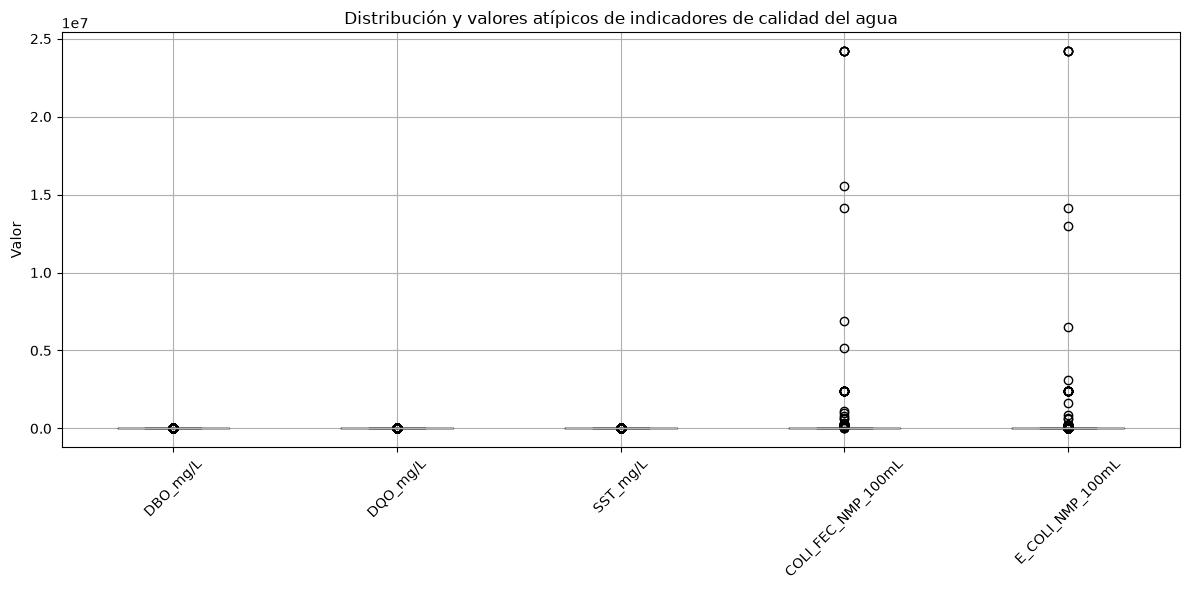

In [32]:
variables_boxplot = [
    "DBO_mg/L",
    "DQO_mg/L",
    "SST_mg/L",
    "COLI_FEC_NMP_100mL",
    "E_COLI_NMP_100mL"
]

plt.figure(figsize=(12, 6))

df_work[variables_boxplot].boxplot()

plt.title("Distribución y valores atípicos de indicadores de calidad del agua")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Para variables tan sesgadas, es mejor verlas individualmente.

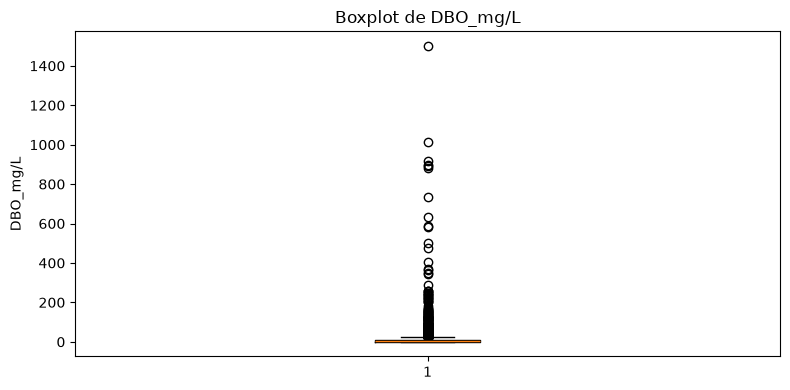

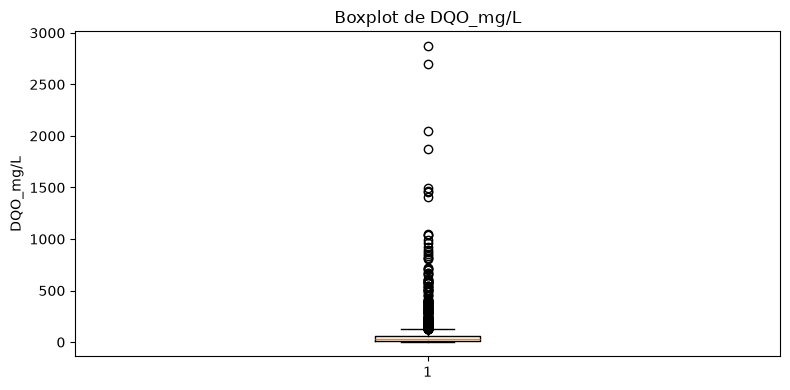

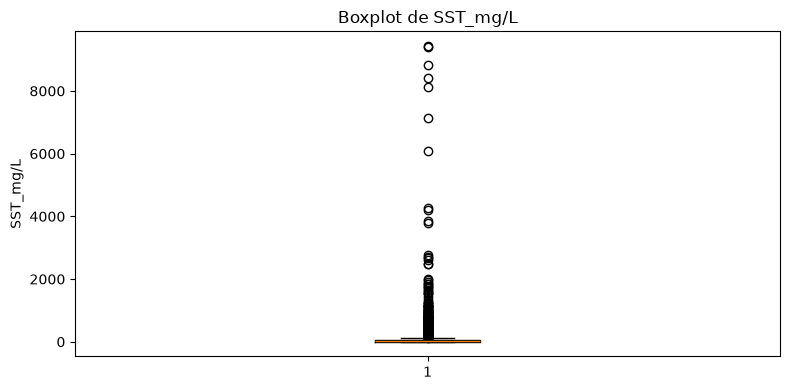

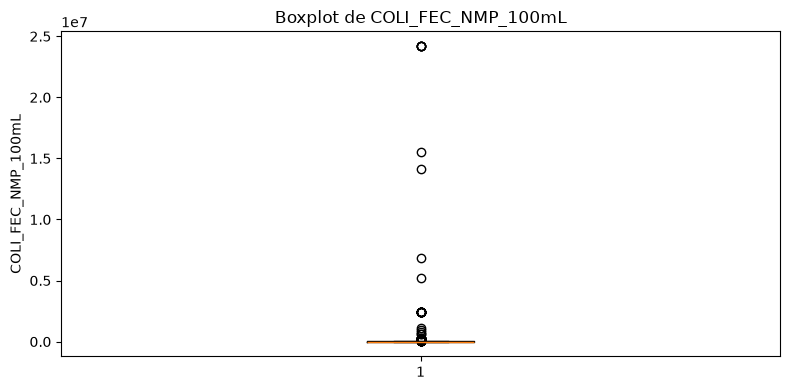

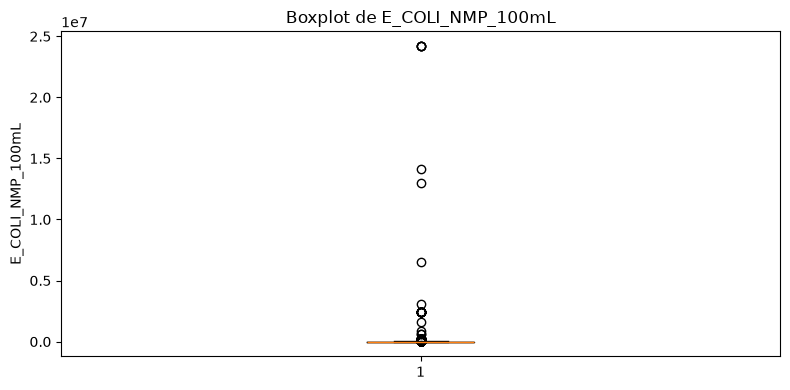

In [33]:
for col in variables_boxplot:
    
    plt.figure(figsize=(8, 4))
    
    plt.boxplot(df_work[col].dropna())
    
    plt.title(f"Boxplot de {col}")
    plt.ylabel(col)
    
    plt.tight_layout()
    plt.show()

## 5.4. Análisis de valores faltantes según la categoría del semáforo<a id='light_missing'></a>
[Back to top](#table_of_contents)

Además del porcentaje global de datos faltantes, se analizará su distribución según la variable objetivo `SEMAFORO`.

Este análisis permitirá determinar si la ausencia de mediciones ambientales se comporta de manera similar entre las categorías Verde, Amarillo y Rojo.

In [34]:
faltantes_por_semaforo = {}

for col in variables_ambientales:
    
    faltantes_por_semaforo[col] = (
        df_work.groupby("SEMAFORO")[col]
        .apply(lambda x: x.isna().mean() * 100)
    )

faltantes_por_semaforo = pd.DataFrame(faltantes_por_semaforo).T

faltantes_por_semaforo.columns.name = None

display(faltantes_por_semaforo)

,Amarillo,Rojo,Verde
DBO_mg/L,3.083700,14.023831,57.142857
DQO_mg/L,3.083700,14.023831,57.142857
SST_mg/L,0.000000,0.366636,0.000000
COLI_FEC_NMP_100mL,3.083700,14.023831,57.063931
E_COLI_NMP_100mL,3.083700,14.023831,57.063931
ENTEROC_NMP_100mL,96.916300,85.976169,43.488556
OD_PORC,22.555066,39.871677,79.321231
OD_PORC_SUP,78.854626,61.778185,24.072612
OD_PORC_MED,91.013216,90.100825,78.137332
OD_PORC_FON,86.519824,81.026581,53.749013


### Interpretación de los faltantes según `SEMAFORO`

La distribución de los valores faltantes presenta diferencias importantes entre las categorías del `SEMAFORO`.

Por ejemplo, `DBO_mg/L`, `DQO_mg/L`, `COLI_FEC_NMP_100mL` y `E_COLI_NMP_100mL` presentan una ausencia de aproximadamente 57% en la categoría Verde, frente a aproximadamente 14% en Rojo y 3% en Amarillo.

También se observan diferencias importantes en `OD_PORC` y las variables de toxicidad.

Estas diferencias indican que los valores faltantes no se distribuyen de manera homogénea entre las categorías del objetivo. Sin embargo, este análisis por sí solo no permite determinar formalmente el mecanismo de ausencia de los datos (MCAR, MAR o MNAR).

## 5.5. Selección de variables para el modelado<a id='model_variable'></a>
[Back to top](#table_of_contents)

Después de analizar los valores faltantes y los estadísticos descriptivos, se decidió no imputar indiscriminadamente todas las variables.

Las variables con porcentajes muy elevados de valores faltantes podrían generar información artificial si una gran parte de sus observaciones fuera reemplazada por un único valor estadístico.

Por esta razón, se establece como criterio inicial excluir del modelado las variables con más del 50% de valores faltantes.

Para las variables numéricas seleccionadas que presentan valores faltantes, se utilizará imputación mediante la **mediana**.

Esta decisión se fundamenta en que varias variables ambientales presentan distribuciones altamente asimétricas y numerosos valores extremos. En estos casos, la mediana es más robusta que la media frente a valores extremos.

Además, los valores extremos no serán eliminados automáticamente, debido a que en un contexto ambiental pueden representar mediciones reales asociadas con niveles elevados de contaminación y, por lo tanto, contener información relevante para el análisis.

In [35]:
# Variables numéricas ambientales
variables_ambientales = [
    "DBO_mg/L",
    "DQO_mg/L",
    "SST_mg/L",
    "COLI_FEC_NMP_100mL",
    "E_COLI_NMP_100mL",
    "ENTEROC_NMP_100mL",
    "OD_PORC",
    "OD_PORC_SUP",
    "OD_PORC_MED",
    "OD_PORC_FON",
    "TOX_D_48_UT",
    "TOX_V_15_UT",
    "TOX_D_48_SUP_UT",
    "TOX_FIS_SUP_15_UT"
]

# Porcentaje de valores faltantes
faltantes_ambientales = (
    df[variables_ambientales]
    .isna()
    .mean()
    .mul(100)
    .sort_values()
)

faltantes_ambientales

SST_mg/L               0.114515
COLI_FEC_NMP_100mL    26.080733
E_COLI_NMP_100mL      26.080733
DQO_mg/L              26.109362
DBO_mg/L              26.109362
TOX_V_15_UT           47.924420
TOX_D_48_UT           48.010306
OD_PORC               48.554251
TOX_FIS_SUP_15_UT     52.075580
OD_PORC_SUP           53.650157
OD_PORC_FON           72.917263
ENTEROC_NMP_100mL     74.119668
TOX_D_48_SUP_UT       78.184941
OD_PORC_MED           86.057830
dtype: float64

In [36]:
# Aplicamos nuestro criterio del 50%

umbral_faltantes = 50

variables_seleccionadas = faltantes_ambientales[
    faltantes_ambientales <= umbral_faltantes
].index.tolist()

variables_excluidas = faltantes_ambientales[
    faltantes_ambientales > umbral_faltantes
].index.tolist()

print("Variables seleccionadas:")
print(variables_seleccionadas)

print("\nVariables excluidas por alto porcentaje de faltantes:")
print(variables_excluidas)


Variables seleccionadas:
['SST_mg/L', 'COLI_FEC_NMP_100mL', 'E_COLI_NMP_100mL', 'DQO_mg/L', 'DBO_mg/L', 'TOX_V_15_UT', 'TOX_D_48_UT', 'OD_PORC']

Variables excluidas por alto porcentaje de faltantes:
['TOX_FIS_SUP_15_UT', 'OD_PORC_SUP', 'OD_PORC_FON', 'ENTEROC_NMP_100mL', 'TOX_D_48_SUP_UT', 'OD_PORC_MED']


### Prevención de fuga de información (Data Leakage)

Para la clasificación del semáforo ambiental se utilizarán principalmente mediciones ambientales observadas y variables de contexto disponibles antes de realizar una predicción.

Se excluirán del conjunto de predictores las variables que representen clasificaciones, reglas de cumplimiento o resultados derivados de los mismos criterios utilizados para construir el semáforo, como las variables `CALIDAD_*`, `CUMPLE_*` y otros indicadores derivados.

La razón es evitar fuga de información (data leakage). Si una variable contiene directa o indirectamente la información utilizada para determinar el `SEMAFORO`, el modelo podría obtener un desempeño artificialmente elevado sin haber aprendido realmente la relación entre las características ambientales y la condición del agua.

Por lo tanto, el modelo buscará estimar el semáforo utilizando características ambientales observadas, en lugar de recibir información que ya contenga la respuesta.

# 6. Imputación<a id='imputation'></a>
[Back to top](#table_of_contents)

## Imputación de valores faltantes

Las variables ambientales seleccionadas contienen valores faltantes debido a que no todos los indicadores fueron medidos en todos los sitios de muestreo.

Para conservar las observaciones disponibles se realizó imputación de los valores faltantes utilizando la **mediana de cada variable**.

Se eligió la mediana debido a la presencia de distribuciones asimétricas y valores extremos observados durante el análisis exploratorio. A diferencia de la media, la mediana presenta mayor robustez frente a valores extremos.

La imputación se aplicó únicamente a las variables seleccionadas para el modelado y no al objetivo `SEMAFORO`.

In [37]:
imputer = SimpleImputer(strategy="median")

df_model = df.copy()

df_model[variables_seleccionadas] = imputer.fit_transform(
    df_model[variables_seleccionadas]
)

In [38]:
faltantes_despues = (
    df_model[variables_seleccionadas]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

faltantes_despues

SST_mg/L              0
COLI_FEC_NMP_100mL    0
E_COLI_NMP_100mL      0
DQO_mg/L              0
DBO_mg/L              0
TOX_V_15_UT           0
TOX_D_48_UT           0
OD_PORC               0
dtype: int64

# 7. Transformación de sesgo y análisis de correlaciones<a id='corr_analysis'></a>
[Back to top](#table_of_contents)

En esta etapa se analizará la distribución de las variables ambientales seleccionadas después de la imputación.

Debido a que algunas variables de calidad del agua presentan distribuciones altamente asimétricas y valores extremos, se calculará el coeficiente de asimetría (skewness).

Las variables con una asimetría positiva elevada serán candidatas a una transformación logarítmica mediante `log1p`. Esta transformación permite reducir el efecto de valores extremadamente grandes y facilitar la comparación entre observaciones.

La transformación se aplicará únicamente a las variables ambientales seleccionadas y no a la variable objetivo `SEMAFORO`.

In [39]:
# Variables que se utilizarán para el análisis
variables_kmeans = variables_seleccionadas.copy()

# Calcular asimetría
skewness = (
    df_model[variables_kmeans]
    .skew()
    .sort_values(ascending=False)
)


print("Coeficiente de asimetría de las variables:")
display(skewness.to_frame(name="Skewness"))

Coeficiente de asimetría de las variables:


,Skewness
TOX_D_48_UT,31.663349
E_COLI_NMP_100mL,23.900057
TOX_V_15_UT,23.032923
COLI_FEC_NMP_100mL,21.784831
SST_mg/L,14.554702
DBO_mg/L,13.990463
DQO_mg/L,10.535867
OD_PORC,-0.118287


## 7.1. Variables candidatas a transformación logarítmica<a id='log_transformation'></a>
[Back to top](#table_of_contents)

In [40]:
# Umbral utilizado para identificar asimetría positiva elevada
umbral_skew = 1

variables_log = skewness[
    skewness > umbral_skew
].index.tolist()

variables_sin_log = skewness[
    skewness <= umbral_skew
].index.tolist()

print("Variables candidatas a transformación log1p:")
print(variables_log)

print("\nVariables que no requieren transformación inicialmente:")
print(variables_sin_log)

Variables candidatas a transformación log1p:
['TOX_D_48_UT', 'E_COLI_NMP_100mL', 'TOX_V_15_UT', 'COLI_FEC_NMP_100mL', 'SST_mg/L', 'DBO_mg/L', 'DQO_mg/L']

Variables que no requieren transformación inicialmente:
['OD_PORC']


In [41]:
# Crear copia para las transformaciones
df_transformado = df_model.copy()

# Aplicar log1p únicamente a las variables identificadas
for variable in variables_log:
    df_transformado[variable] = np.log1p(
        df_transformado[variable]
    )

print("Transformación aplicada a:")
print(variables_log)

Transformación aplicada a:
['TOX_D_48_UT', 'E_COLI_NMP_100mL', 'TOX_V_15_UT', 'COLI_FEC_NMP_100mL', 'SST_mg/L', 'DBO_mg/L', 'DQO_mg/L']


## 7.2. Comparación de sesgo<a id='skewness'></a>
[Back to top](#table_of_contents)

In [42]:
# Comparación del skewness antes y después
comparacion_skew = pd.DataFrame({
    "Antes": df_model[variables_kmeans].skew(),
    "Después": df_transformado[variables_kmeans].skew()
})

comparacion_skew["Cambio"] = (
    comparacion_skew["Después"] -
    comparacion_skew["Antes"]
)

display(
    comparacion_skew.sort_values(
        "Antes",
        ascending=False
    )
)

,Antes,Después,Cambio
TOX_D_48_UT,31.663349,10.334424,-21.328925
E_COLI_NMP_100mL,23.900057,0.112837,-23.787220
TOX_V_15_UT,23.032923,6.667230,-16.365692
COLI_FEC_NMP_100mL,21.784831,-0.467985,-22.252816
SST_mg/L,14.554702,0.847525,-13.707177
DBO_mg/L,13.990463,1.649048,-12.341415
DQO_mg/L,10.535867,0.582786,-9.953080
OD_PORC,-0.118287,-0.118287,0.000000


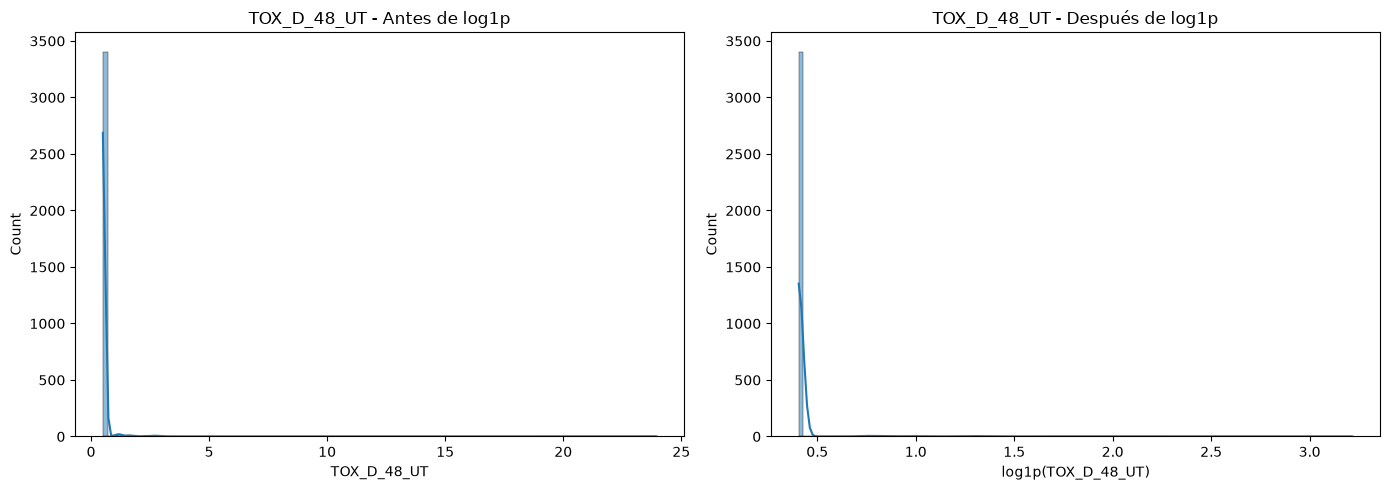

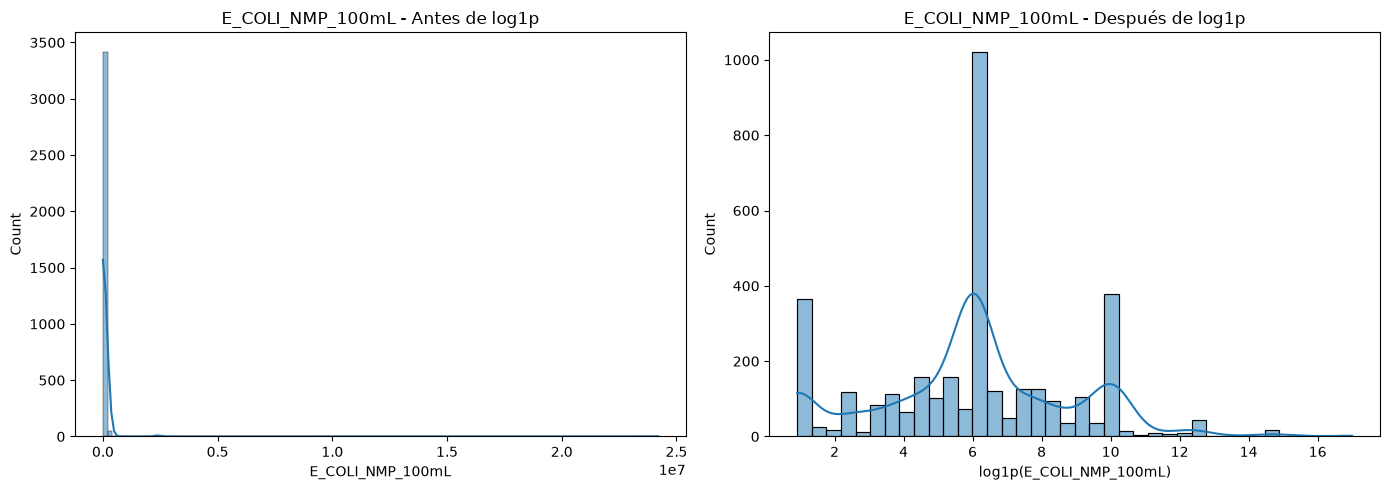

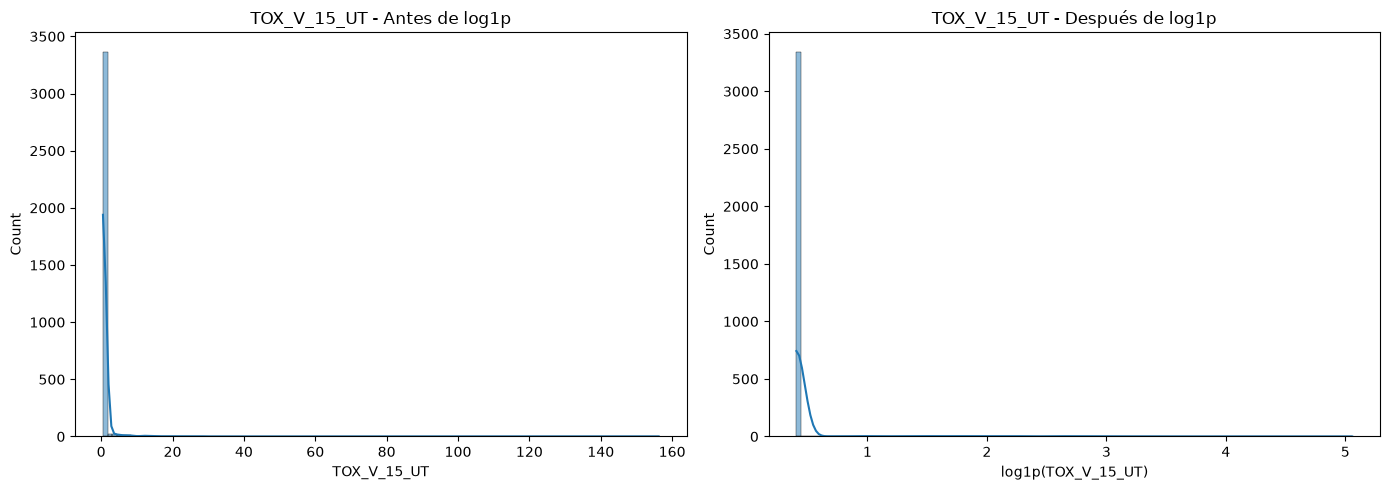

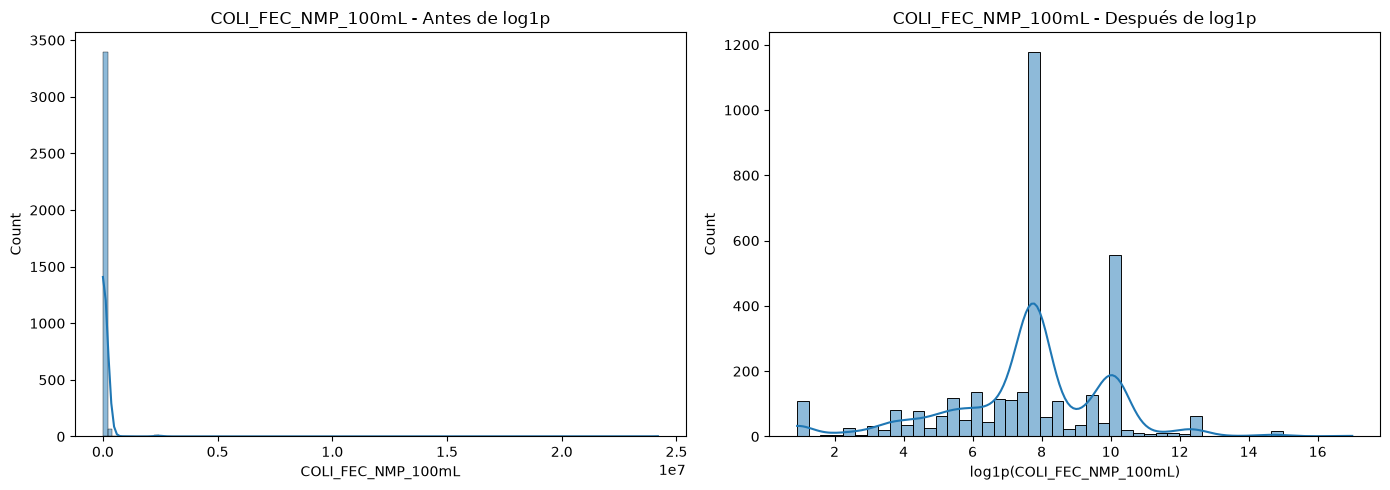

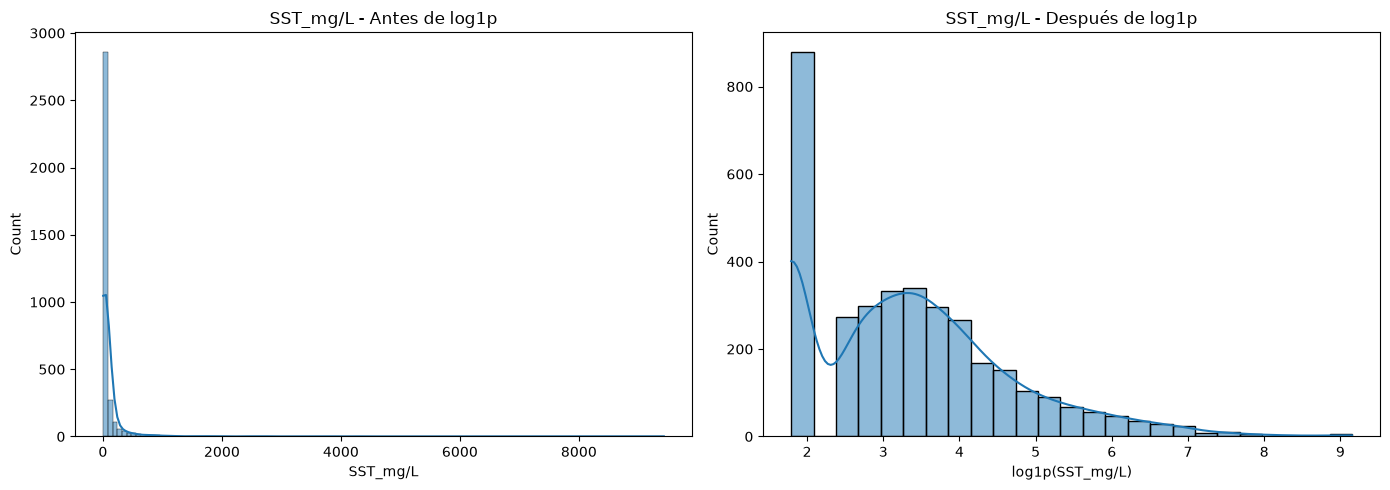

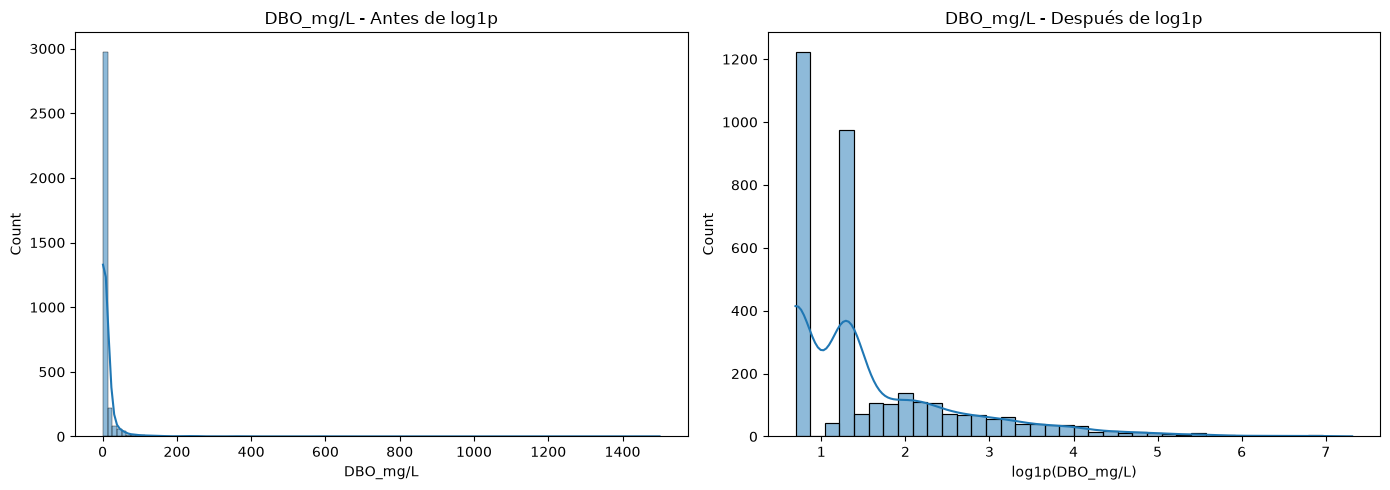

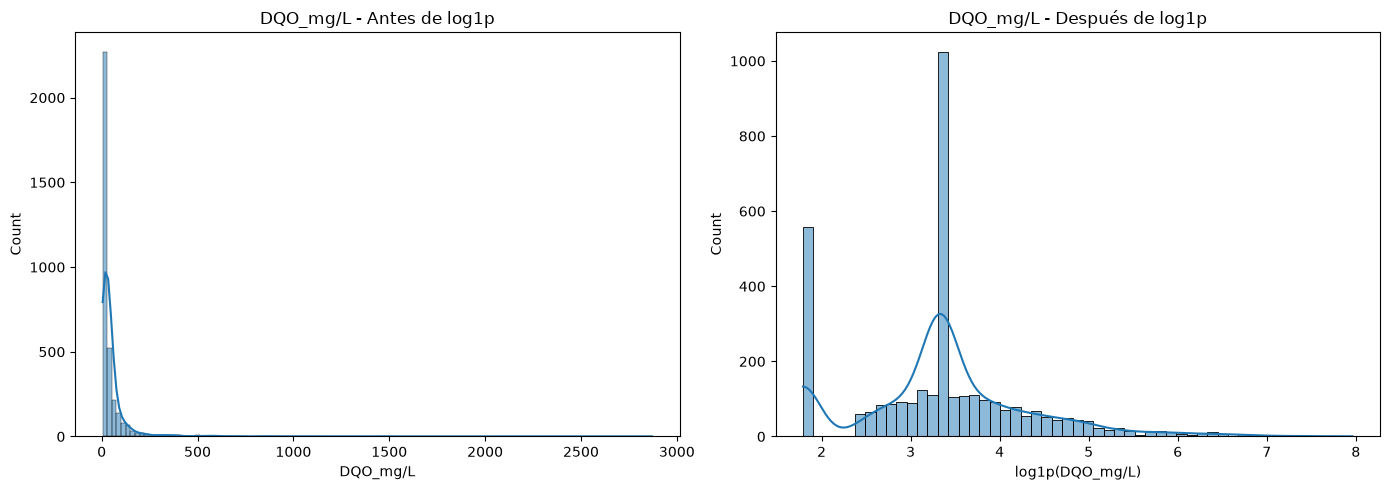

In [43]:
for variable in variables_log:

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(
        df_model[variable],
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title(
        f"{variable} - Antes de log1p"
    )
    axes[0].set_xlabel(variable)

    sns.histplot(
        df_transformado[variable],
        kde=True,
        ax=axes[1]
    )

    axes[1].set_title(
        f"{variable} - Después de log1p"
    )
    axes[1].set_xlabel(f"log1p({variable})")

    plt.tight_layout()
    plt.show()

### Interpretación de la transformación logarítmica

La transformación `log1p` redujo considerablemente la asimetría positiva de varias variables ambientales.

La reducción fue especialmente notable en `E_COLI_NMP_100mL`, `COLI_FEC_NMP_100mL`, `SST_mg/L` y `DQO_mg/L`.

Sin embargo, algunas variables, particularmente las relacionadas con toxicidad, mantienen una asimetría considerable después de la transformación.

Por lo tanto, `log1p` se interpreta como una estrategia para reducir el efecto de las magnitudes extremas y mejorar la distribución de los datos, pero no como un procedimiento que necesariamente convierta las variables en distribuciones normales.

| Variable             | Antes |   Después | Interpretación                                |
| -------------------- | ----: | --------: | --------------------------------------------- |
| `TOX_D_48_UT`        | 31.66 |     10.33 | ↓ bastante, pero sigue extremadamente sesgada |
| `E_COLI_NMP_100mL`   | 23.90 |  **0.11** | **Excelente**                                   |
| `TOX_V_15_UT`        | 23.03 |      6.67 | ↓ bastante, pero sigue muy sesgada            |
| `COLI_FEC_NMP_100mL` | 21.78 | **-0.47** | **Muy buena**                                   |
| `SST_mg/L`           | 14.55 |  **0.85** | **Aceptable**                                   |
| `DBO_mg/L`           | 13.99 |      1.65 | ⚠️ Mejoró, pero continúa sesgada              |
| `DQO_mg/L`           | 10.54 |  **0.58** | **Aceptable**                                   |
| `OD_PORC`            | -0.12 |     -0.12 | **Ya tenía distribución bastante equilibrada**  |


## 7.3. Matriz de correlación<a id='correlation'></a>
[Back to top](#table_of_contents)

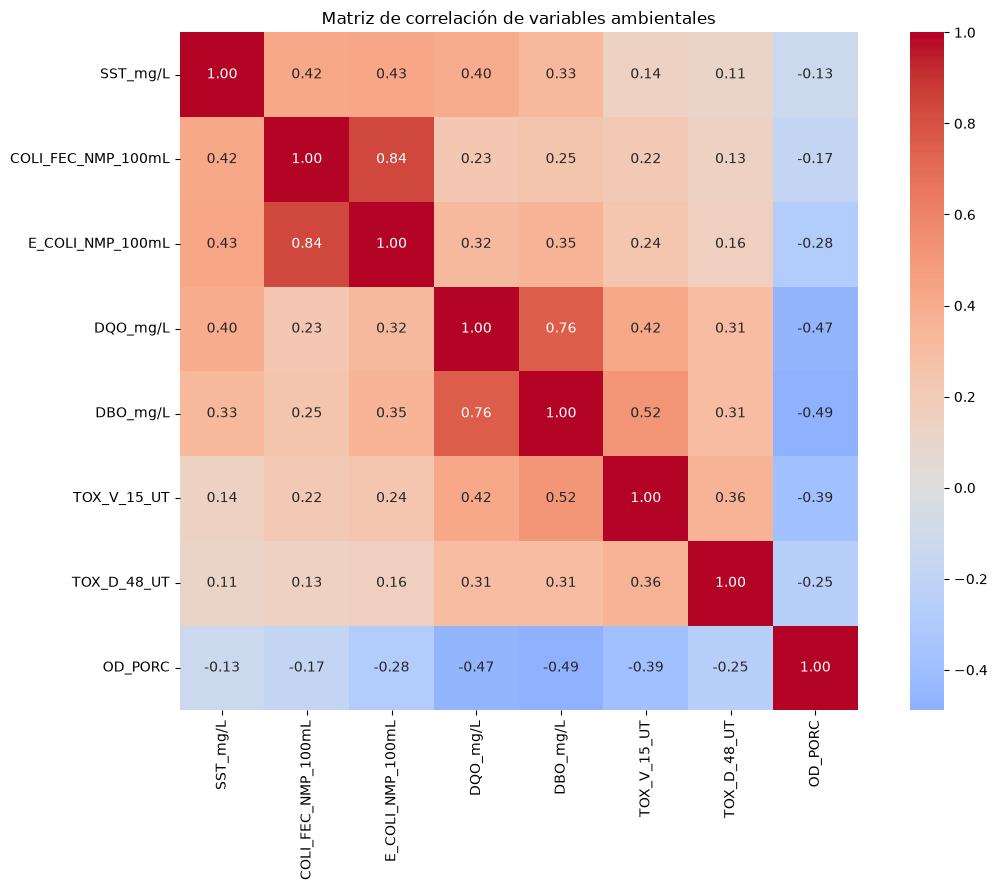

In [44]:
# Matriz de correlación de las variables ambientales
matriz_corr = (
    df_transformado[variables_kmeans]
    .corr()
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Matriz de correlación de variables ambientales"
)

plt.tight_layout()
plt.show()

### 7.3.1 Pares altamente correlacionados<a id='corr_pairs'></a>
[Back to top](#table_of_contents)

In [45]:
# Identificar pares con correlación absoluta >= 0.80

umbral_corr = 0.80

pares_correlacionados = []

for i in range(len(matriz_corr.columns)):
    for j in range(i + 1, len(matriz_corr.columns)):

        correlacion = matriz_corr.iloc[i, j]

        if abs(correlacion) >= umbral_corr:

            pares_correlacionados.append({
                "Variable 1": matriz_corr.columns[i],
                "Variable 2": matriz_corr.columns[j],
                "Correlación": correlacion
            })

correlaciones_altas = pd.DataFrame(
    pares_correlacionados
).sort_values(
    "Correlación",
    key=lambda x: abs(x),
    ascending=False
)

display(correlaciones_altas)

,Variable 1,Variable 2,Correlación
0,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,0.835057


## 7.4. Mapa de calor limpio<a id='heatmap'></a>
[Back to top](#table_of_contents)

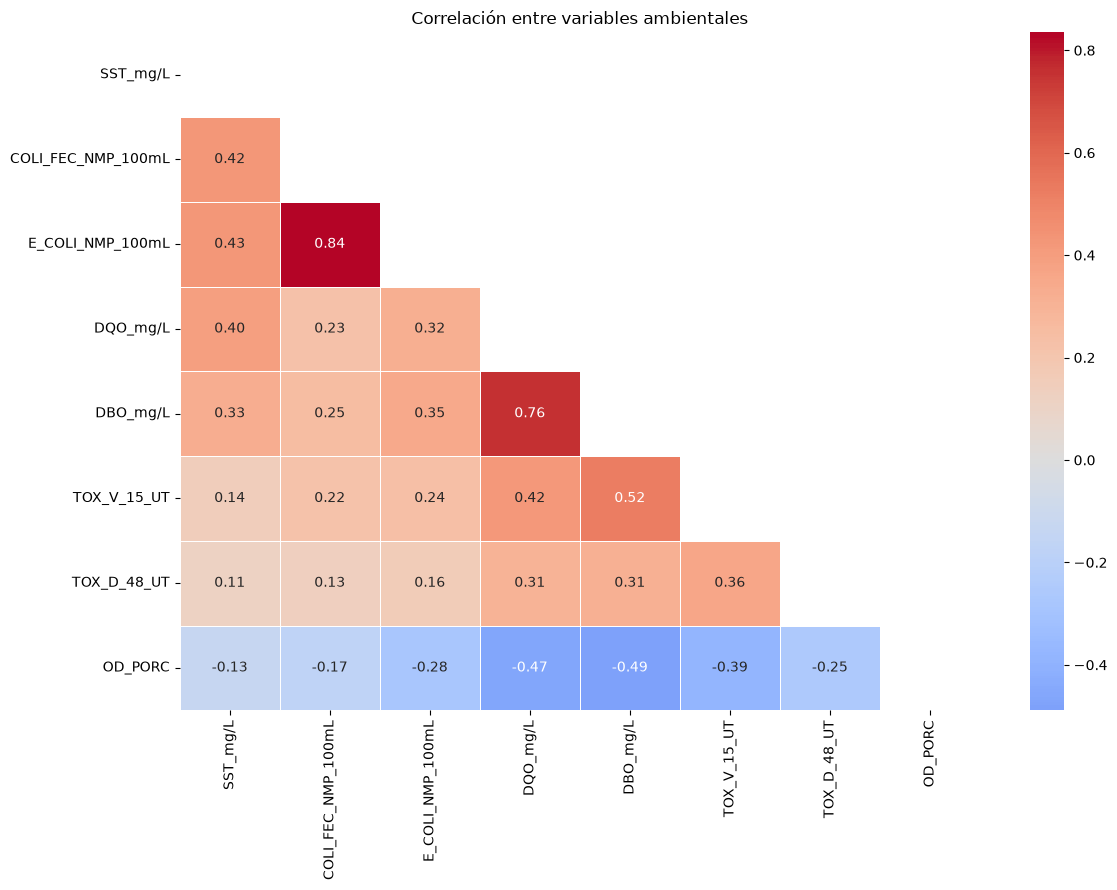

In [46]:
plt.figure(figsize=(12, 9))

mask = np.triu(
    np.ones_like(matriz_corr, dtype=bool)
)

sns.heatmap(
    matriz_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlación entre variables ambientales"
)

plt.tight_layout()
plt.show()

# 8. Preparación de variables para el modelado<a id='model_prep'></a>
[Back to top](#table_of_contents)

Después del tratamiento de valores faltantes, la transformación de variables asimétricas y el análisis de correlaciones, se debe preparar la matriz de características para las técnicas de Machine Learning.

Las variables ambientales presentan escalas muy diferentes. Por ejemplo, los indicadores microbiológicos pueden alcanzar valores de millones, mientras que las variables de toxicidad y oxígeno disuelto se encuentran en escalas mucho menores.

Esta diferencia de magnitudes puede afectar especialmente a algoritmos basados en distancia, como K-Means, y también puede influir en técnicas como PCA.

Por esta razón, antes del modelado se realizará un proceso de escalamiento de las variables.

## 8.1. Comparación de métodos de escalamiento<a id='scaler'></a>
[Back to top](#table_of_contents)

Se evaluarán dos métodos de escalamiento:

- **StandardScaler:** centra las variables alrededor de media 0 y desviación estándar 1.
- **RobustScaler:** utiliza la mediana y el rango intercuartílico, por lo que presenta mayor resistencia a valores extremos.

Debido a que el conjunto de datos contiene valores atípicos importantes, resulta conveniente comparar ambos métodos antes de seleccionar el utilizado en K-Means.

In [47]:
scaler_standard = StandardScaler()
scaler_robust = RobustScaler()

X = df_transformado[variables_kmeans].copy()

X_standard = scaler_standard.fit_transform(X)
X_robust = scaler_robust.fit_transform(X)

X_standard = pd.DataFrame(
    X_standard,
    columns=variables_kmeans,
    index=X.index
)

X_robust = pd.DataFrame(
    X_robust,
    columns=variables_kmeans,
    index=X.index
)

print("Resumen StandardScaler:")
display(X_standard.describe().T)

print("\nResumen RobustScaler:")
display(X_robust.describe().T)

Resumen StandardScaler:


,count,mean,std,min,25%,50%,75%,max
SST_mg/L,3493.0,-5.288895e-17,1.000143,-1.170699,-1.170699,-0.087678,0.536706,4.368416
COLI_FEC_NMP_100mL,3493.0,-1.668036e-16,1.000143,-2.809685,-0.356039,0.077584,0.717528,3.953171
E_COLI_NMP_100mL,3493.0,3.742910e-16,1.000143,-1.788008,-0.533867,0.003866,0.608002,3.824171
DQO_mg/L,3493.0,8.136762e-18,1.000143,-1.555951,-0.471819,-0.015050,0.427933,4.615539
DBO_mg/L,3493.0,3.824278e-16,1.000143,-0.840368,-0.840368,-0.281290,0.431291,5.369328
TOX_V_15_UT,3493.0,-2.034190e-16,1.000143,-0.182068,-0.182068,-0.182068,-0.182068,12.773298
TOX_D_48_UT,3493.0,-1.651763e-15,1.000143,-0.136758,-0.136758,-0.136758,-0.136758,23.042317
OD_PORC,3493.0,-7.323086e-17,1.000143,-2.718016,0.000367,0.039574,0.087494,6.913945



Resumen RobustScaler:


,count,mean,std,min,25%,50%,75%,max
SST_mg/L,3493.0,0.051351,0.585768,-0.634308,-0.634308,0.0,0.365692,2.609863
COLI_FEC_NMP_100mL,3493.0,-0.072268,0.931608,-2.689418,-0.403909,0.0,0.596091,3.610010
E_COLI_NMP_100mL,3493.0,-0.003386,0.875882,-1.569246,-0.470924,0.0,0.529076,3.345659
DQO_mg/L,3493.0,0.016726,1.111577,-1.712585,-0.507661,0.0,0.492339,5.146517
DBO_mg/L,3493.0,0.221199,0.786487,-0.439644,-0.439644,0.0,0.560356,4.443501
TOX_V_15_UT,3493.0,0.065382,0.359159,0.000000,0.000000,0.0,0.000000,4.652372
TOX_D_48_UT,3493.0,0.016587,0.121306,0.000000,0.000000,0.0,0.000000,2.811369
OD_PORC,3493.0,-0.454208,11.479057,-31.650000,-0.450000,0.0,0.550000,78.900000


## Verificación del tratamiento de valores faltantes

Antes de aplicar técnicas de reducción de dimensionalidad y aprendizaje automático, se verifica que el tratamiento de los valores faltantes no haya introducido valores artificiales en las variables ambientales.

Esta revisión es importante porque un valor faltante representa una ausencia de medición y no necesariamente un valor igual a cero. Por ello, se deben identificar las variables que todavía contienen valores faltantes y verificar los valores mínimos, medianas y máximos antes de seleccionar la estrategia definitiva de imputación.

In [48]:
variables_ambientales = [
    "SST_mg/L",
    "COLI_FEC_NMP_100mL",
    "E_COLI_NMP_100mL",
    "DQO_mg/L",
    "DBO_mg/L",
    "TOX_V_15_UT",
    "TOX_D_48_UT",
    "OD_PORC"
]

print("Valores faltantes:")
print(df[variables_ambientales].isna().sum())

print("\nValores iguales a cero:")
print((df[variables_ambientales] == 0).sum())

print("\nValores mínimos:")
print(df[variables_ambientales].min())

print("\nMedianas:")
print(df[variables_ambientales].median())

Valores faltantes:
SST_mg/L                 4
COLI_FEC_NMP_100mL     911
E_COLI_NMP_100mL       911
DQO_mg/L               912
DBO_mg/L               912
TOX_V_15_UT           1674
TOX_D_48_UT           1677
OD_PORC               1696
dtype: int64

Valores iguales a cero:
SST_mg/L              0
COLI_FEC_NMP_100mL    0
E_COLI_NMP_100mL      0
DQO_mg/L              0
DBO_mg/L              0
TOX_V_15_UT           0
TOX_D_48_UT           0
OD_PORC               0
dtype: int64

Valores mínimos:
SST_mg/L              5.0
COLI_FEC_NMP_100mL    1.5
E_COLI_NMP_100mL      1.5
DQO_mg/L              5.0
DBO_mg/L              1.0
TOX_V_15_UT           0.5
TOX_D_48_UT           0.5
OD_PORC               5.0
dtype: float64

Medianas:
SST_mg/L                24.30
COLI_FEC_NMP_100mL    2400.00
E_COLI_NMP_100mL       424.00
DQO_mg/L                27.01
DBO_mg/L                 2.63
TOX_V_15_UT              0.50
TOX_D_48_UT              0.50
OD_PORC                 68.30
dtype: float64


Las variables ambientales presentan distribuciones sesgadas y valores extremos asociados a eventos reales de contaminación.

Por esta razón se utilizó RobustScaler, que emplea la mediana y el rango intercuartílico (IQR), siendo más adecuado que StandardScaler para datos ambientales.

# 9. K-Means<a id='k_means'></a>
[Back to top](#table_of_contents)

### Selección de variables para K-Means

Para el análisis de clustering se seleccionan las principales variables fisicoquímicas y microbiológicas relacionadas con la calidad del agua:

- DBO
- DQO
- SST
- Coliformes fecales
- E. coli
- Oxígeno disuelto

Aunque las variables de toxicidad fueron imputadas anteriormente para conservar la información del conjunto de datos y permitir otros análisis, se excluyen del K-Means debido a su elevada proporción de valores faltantes originales.

De esta manera, los grupos generados por K-Means se basarán principalmente en variables ambientales con mayor disponibilidad de mediciones.

El objetivo no es eliminar estas variables del dataset, sino utilizar un subconjunto más confiable para el proceso de clustering.

In [49]:
variables_kmeans = [
    'DBO_mg/L',
    'DQO_mg/L',
    'SST_mg/L',
    'COLI_FEC_NMP_100mL',
    'E_COLI_NMP_100mL',
    'OD_PORC'
]

### Preparación de la matriz de características para K-Means

Se utilizarán las variables ambientales seleccionadas después del tratamiento de valores faltantes y de las transformaciones aplicadas a las distribuciones asimétricas.

Posteriormente se utilizará RobustScaler para colocar las variables en escalas comparables.

Esto es especialmente importante para K-Means porque el algoritmo calcula distancias entre observaciones. Sin escalamiento, una variable con valores numéricamente grandes podría tener una influencia desproporcionada sobre la formación de los grupos.

RobustScaler resulta adecuado en este caso porque utiliza la mediana y el rango intercuartílico (IQR), reduciendo la influencia de valores extremos.

In [50]:
# Seleccionar las variables utilizadas en K-Means
X_kmeans = df_transformado[variables_kmeans].copy()

# Crear y aplicar RobustScaler específicamente para K-Means
scaler_kmeans = RobustScaler()

X_kmeans = scaler_kmeans.fit_transform(X_kmeans)

# Convertir nuevamente a DataFrame
X_kmeans = pd.DataFrame(
    X_kmeans,
    columns=variables_kmeans,
    index=df_transformado.index
)

print("Dimensiones de X_kmeans:", X_kmeans.shape)

display(X_kmeans.head())

Dimensiones de X_kmeans: (3493, 6)


,DBO_mg/L,DQO_mg/L,SST_mg/L,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,OD_PORC
0,0.484334,0.751617,-0.237830,-0.283881,-0.445178,0.0
1,0.000000,0.000000,-0.634308,0.000000,0.000000,0.0
2,0.000000,0.000000,-0.634308,0.000000,0.000000,0.0
3,0.000000,0.000000,-0.231401,0.000000,0.000000,0.0
4,0.000000,0.000000,-0.634308,0.000000,0.000000,0.0


### Verificación de la matriz para K-Means

Antes de ejecutar el algoritmo se verifica que la matriz de características tenga las dimensiones esperadas y que no contenga valores faltantes.

Esta comprobación evita que errores de preparación de datos se confundan posteriormente con problemas del algoritmo de clustering.

In [51]:
print("Dimensiones:", X_kmeans.shape)

print("\nValores faltantes:")
print(X_kmeans.isna().sum())

print("\nValores infinitos:")
print(np.isinf(X_kmeans).sum().sum())


Dimensiones: (3493, 6)

Valores faltantes:
DBO_mg/L              0
DQO_mg/L              0
SST_mg/L              0
COLI_FEC_NMP_100mL    0
E_COLI_NMP_100mL      0
OD_PORC               0
dtype: int64

Valores infinitos:
0


## Selección del número de clusters

K-Means requiere definir previamente el número de grupos (`k`).

Como no se conoce de antemano cuál es el número adecuado de grupos de sitios de calidad del agua, se evaluarán diferentes valores de `k`.

Se utilizarán dos criterios:

- **Método del codo:** analiza la disminución de la inercia a medida que aumenta el número de clusters.
- **Coeficiente de Silhouette:** evalúa qué tan bien separadas y cohesionadas están las observaciones dentro de los grupos.

Se probarán valores de `k` entre 2 y 10. La decisión final se tomará considerando ambos criterios y la interpretabilidad de los grupos obtenidos.

In [52]:
inercia = []
silhouette = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_kmeans)

    inercia.append(kmeans.inertia_)

    silhouette.append(
        silhouette_score(X_kmeans, labels)
    )

resultados_k = pd.DataFrame({
    "k": range(2, 11),
    "Inercia": inercia,
    "Silhouette": silhouette
})

display(resultados_k)

,k,Inercia,Silhouette
0,2,222155.705322,0.644323
1,3,94370.158133,0.672682
2,4,68135.014649,0.652512
3,5,43139.440699,0.669177
4,6,35727.685971,0.609605
5,7,28670.428232,0.606377
6,8,24015.070493,0.605875
7,9,21018.692705,0.575493
8,10,18903.849796,0.560707


### Evaluación del número de clusters

La gráfica de inercia permite observar el punto a partir del cual aumentar el número de clusters produce mejoras cada vez menores.

El coeficiente de Silhouette complementa este análisis, ya que valores más altos indican una mejor separación entre los grupos y una mayor cohesión interna.

Ambos criterios se analizarán conjuntamente para seleccionar un número de clusters adecuado.

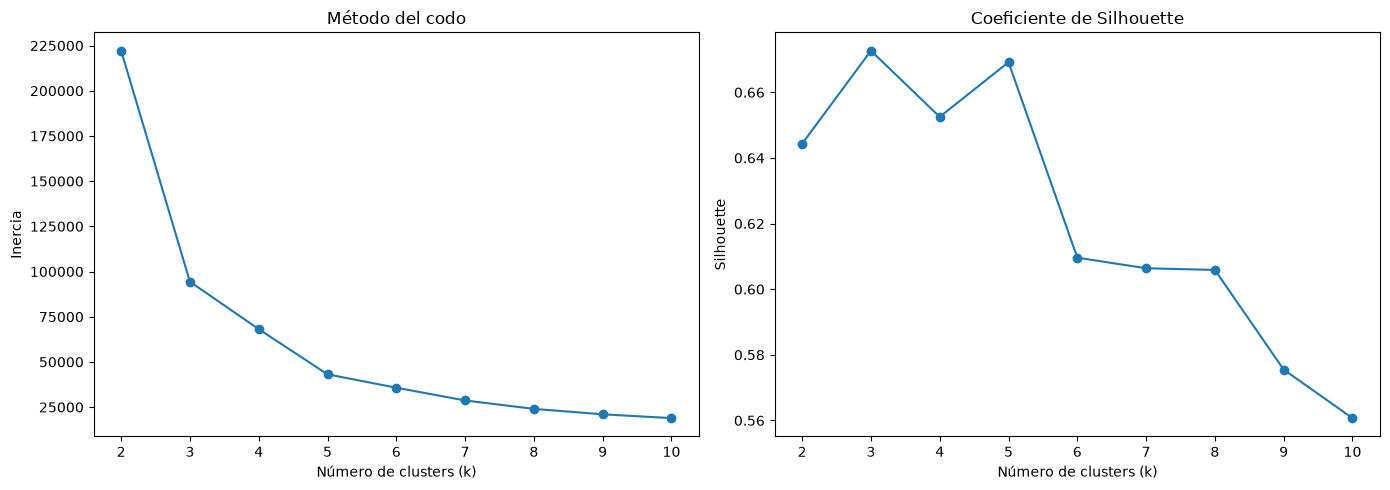

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
axes[0].plot(
    resultados_k["k"],
    resultados_k["Inercia"],
    marker="o"
)

axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].set_xticks(resultados_k["k"])

# Silhouette
axes[1].plot(
    resultados_k["k"],
    resultados_k["Silhouette"],
    marker="o"
)

axes[1].set_title("Coeficiente de Silhouette")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette")
axes[1].set_xticks(resultados_k["k"])

plt.tight_layout()
plt.show()

## Selección del número de clusters

Para determinar el número adecuado de clusters se evaluaron valores de k entre 2 y 10 utilizando dos criterios: el método del codo y el coeficiente de Silhouette.

El método del codo permite observar cómo disminuye la inercia al incrementar el número de clusters. Por otro lado, el coeficiente de Silhouette permite evaluar qué tan bien separados y cohesionados se encuentran los grupos.

Los resultados muestran que:

- k = 3 presenta el mayor coeficiente de Silhouette (0.6727).
- k = 5 presenta también un valor elevado (0.6692), pero ligeramente inferior.
- A partir de k = 6 el coeficiente de Silhouette disminuye de forma considerable.
- La inercia presenta una reducción importante al pasar de 2 a 3 clusters y posteriormente las mejoras son progresivamente menores.

Por lo tanto, se selecciona **k = 3** como número de clusters para el análisis K-Means.

Esta selección busca obtener grupos suficientemente diferenciados y, al mismo tiempo, mantener una solución sencilla de interpretar y visualizar posteriormente en el mapa.

## K-Means Definitivo

In [54]:
# K-Means definitivo
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_kmeans)

# Guardar el cluster en el dataset
df_transformado["CLUSTER"] = clusters

print("Clusters creados correctamente.")
print(
    df_transformado["CLUSTER"]
    .value_counts()
    .sort_index()
)

Clusters creados correctamente.
CLUSTER
0    2390
1     614
2     489
Name: count, dtype: int64


In [55]:
# Resumen de cantidad de observaciones por cluster

resumen_clusters = (
    df_transformado["CLUSTER"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Cantidad")
)

resumen_clusters["Porcentaje"] = (
    resumen_clusters["Cantidad"]
    / len(df_transformado)
    * 100
)

display(resumen_clusters)

,Cluster,Cantidad,Porcentaje
0,0,2390,68.422559
1,1,614,17.578013
2,2,489,13.999427


### Caracterizar los clusteres

In [56]:
# Variables utilizadas en el clustering
variables_kmeans

# Promedio de las variables ambientales por cluster

perfil_clusters = (
    df_transformado
    .groupby("CLUSTER")[variables_kmeans]
    .mean()
    .round(3)
)

display(perfil_clusters)

,DBO_mg/L,DQO_mg/L,SST_mg/L,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,OD_PORC
CLUSTER,,,,,,
0,1.400,3.276,3.151,7.089,5.398,67.474
1,1.223,2.805,3.577,8.164,6.369,100.201
2,2.974,4.381,4.019,9.385,8.773,25.792


In [57]:
# Mediana de las variables ambientales por cluster

mediana_clusters = (
    df_transformado
    .groupby("CLUSTER")[variables_kmeans]
    .median()
    .round(3)
)

display(mediana_clusters)


,DBO_mg/L,DQO_mg/L,SST_mg/L,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,OD_PORC
CLUSTER,,,,,,
0,1.289,3.333,3.090,7.784,6.052,68.3
1,0.693,2.774,3.370,8.004,6.320,96.6
2,3.020,4.369,4.029,10.086,9.788,28.4


In [58]:
# Centroides de los clusters en escala estandarizada

centroides = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=variables_kmeans
)

centroides.index.name = "CLUSTER"

display(
    centroides.round(3)
)

,DBO_mg/L,DQO_mg/L,SST_mg/L,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,OD_PORC
CLUSTER,,,,,,
0,0.082,-0.063,-0.035,-0.272,-0.200,-0.413
1,-0.049,-0.586,0.153,0.149,0.097,15.950
2,1.242,1.165,0.348,0.627,0.831,-21.254


In [59]:
print("OD_PORC en df_transformado:")
display(
    df_transformado["OD_PORC"].describe()
)

OD_PORC en df_transformado:


count    3493.000000
mean       67.391583
std        22.958114
min         5.000000
25%        67.400000
50%        68.300000
75%        69.400000
max       226.100000
Name: OD_PORC, dtype: float64

In [60]:
print("OD_PORC en X_kmeans:")
display(
    X_kmeans["OD_PORC"].describe()
)

OD_PORC en X_kmeans:


count    3493.000000
mean       -0.454208
std        11.479057
min       -31.650000
25%        -0.450000
50%         0.000000
75%         0.550000
max        78.900000
Name: OD_PORC, dtype: float64

In [61]:
print("Centroides calculados por K-Means:")

print(
    pd.DataFrame(
        kmeans.cluster_centers_,
        columns=variables_kmeans
    )
)

Centroides calculados por K-Means:
   DBO_mg/L  DQO_mg/L  SST_mg/L  COLI_FEC_NMP_100mL  E_COLI_NMP_100mL  \
0  0.081603 -0.063375 -0.035240           -0.272182         -0.199968   
1 -0.048610 -0.585889  0.152516            0.148817          0.096936   
2  1.242258  1.164882  0.347543            0.627218          0.831447   

     OD_PORC  
0  -0.412983  
1  15.950497  
2 -21.253834  


In [62]:
# Revisar valores extremos de OD_PORC

od_extremos = df_transformado[
    df_transformado["OD_PORC"] > 100
][["OD_PORC"]]

print("Cantidad de valores OD_PORC > 100:")
print(len(od_extremos))

display(
    od_extremos.sort_values(
        "OD_PORC",
        ascending=False
    ).head(20)
)

Cantidad de valores OD_PORC > 100:
215


,OD_PORC
324,226.10
54,200.00
3365,182.60
2729,180.10
979,179.50
2730,165.80
289,158.80
3414,157.30
3407,150.00
3406,150.00


In [63]:
# Distribución de OD_PORC por rangos

rangos_od = pd.cut(
    df_transformado["OD_PORC"],
    bins=[0, 50, 70, 80, 100, 150, 200, float("inf")]
)

display(
    rangos_od.value_counts()
    .sort_index()
    .to_frame("Cantidad")
)


,Cantidad
OD_PORC,
"(0.0, 50.0]",544
"(50.0, 70.0]",2092
"(70.0, 80.0]",163
"(80.0, 100.0]",479
"(100.0, 150.0]",207
"(150.0, 200.0]",7
"(200.0, inf]",1


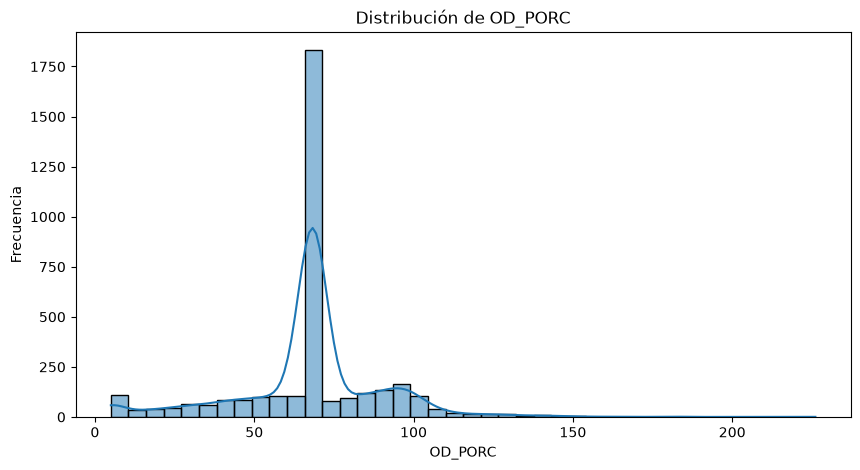

In [64]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_transformado["OD_PORC"],
    bins=40,
    kde=True
)

plt.title("Distribución de OD_PORC")
plt.xlabel("OD_PORC")
plt.ylabel("Frecuencia")

plt.show()

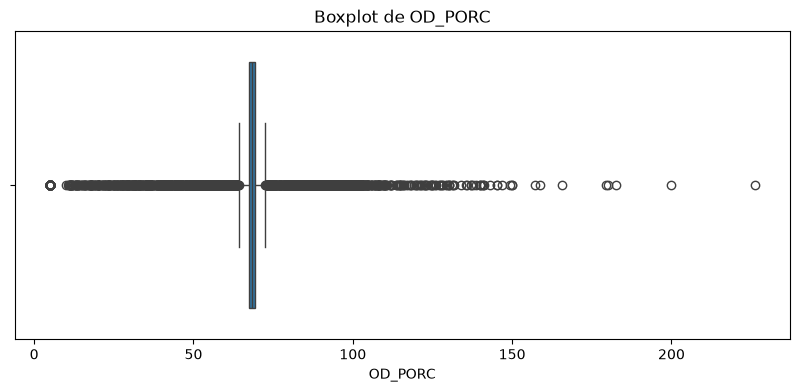

In [65]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_transformado["OD_PORC"]
)

plt.title("Boxplot de OD_PORC")
plt.xlabel("OD_PORC")

plt.show()

El problema no es que los 215 valores >100 sean automáticamente errores. El problema es que RobustScaler está dando un peso desproporcionado a OD_PORC debido a su IQR extremadamente pequeño.

El histograma muestra que la distribución no es simplemente una distribución con unos pocos valores extremos: hay una concentración enorme alrededor de 68, otro grupo de valores aproximadamente entre 80–100 y una cola de valores superiores

# 10. Clasificación: Árbol de Decisión <a id='decision_tree'></a>
[Back to top](#table_of_contents)

Se entrena al modelo de decision tree o **Árbol de Decisión** para clasificar la variable objetivo: `SEMAFORO` (Verde / Amarillo / Rojo), utilizando las variables ambientales seleccionadas en la sección 4.2: (`variables_seleccionadas`), ya imputadas en `df_model`. Se mantuvo el mismo criterio de prevención de fuga de información descrito en sección 4.2: se excluyen del conjunto de predictores las variables `CALIDAD_*` y `CUMPLE_*`, ya que se derivan de los mismos criterios que definen el `SEMAFORO`. A diferencia de K-Means, el árbol de decisión no requiere escalamiento (`StandardScaler`/`RobustScaler`) ni transformación logarítmica, porque es un modelo basado en particiones (splits) invariante a la escala de las variables. Por esta razón se utilizo `df_model` (variables imputadas) en lugar de `df_transformado`.

## 10.1. Selección de variables predictoras y variable objetivo <a id='dt_variables'></a>
[Back to top](#table_of_contents)

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

In [67]:
# Variables predictoras: variables ambientales seleccionadas y ya imputadas (sección 4.2 / 6)
X = df_model[variables_seleccionadas].copy()

# Variable objetivo
y = df_model["SEMAFORO"].copy()

print("Variables predictoras utilizadas:")
print(variables_seleccionadas)
print("\nDimensiones de X:", X.shape)
print("\nDistribución de la variable objetivo:")
print(y.value_counts())

Variables predictoras utilizadas:
['SST_mg/L', 'COLI_FEC_NMP_100mL', 'E_COLI_NMP_100mL', 'DQO_mg/L', 'DBO_mg/L', 'TOX_V_15_UT', 'TOX_D_48_UT', 'OD_PORC']

Dimensiones de X: (3493, 8)

Distribución de la variable objetivo:
SEMAFORO
Verde       1267
Amarillo    1135
Rojo        1091
Name: count, dtype: int64


## 10.2. Label Encoding de la variable objetivo <a id='dt_encoding'></a>
[Back to top](#table_of_contents)

In [68]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Clases originales y su codificación:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Clases originales y su codificación:
{'Amarillo': np.int64(0), 'Rojo': np.int64(1), 'Verde': np.int64(2)}


## 10.3. División en conjunto de entrenamiento y prueba <a id='dt_split'></a>
[Back to top](#table_of_contents)

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (2794, 8)
Tamaño de prueba: (699, 8)


## 10.4. Modelo base (sin poda) <a id='dt_base'></a>
[Back to top](#table_of_contents)

Se entrena primero un árbol sin restricciones de profundidad con el fin de observar el comportamiento del modelo sin poda, de ese modo evidenciar el riesgo de posible sobreajuste.

In [70]:
arbol_base = DecisionTreeClassifier(random_state=42)
arbol_base.fit(X_train, y_train)

y_pred_base = arbol_base.predict(X_test)

print("Accuracy (modelo base, sin poda):", accuracy_score(y_test, y_pred_base))
print("Profundidad del árbol:", arbol_base.get_depth())
print("Número de hojas:", arbol_base.get_n_leaves())

Accuracy (modelo base, sin poda): 0.8884120171673819
Profundidad del árbol: 27
Número de hojas: 248


## 10.5. Control de sobreajuste: selección de `max_depth` <a id='dt_depth'></a>
[Back to top](#table_of_contents)

El árbol sin poda tiende a memorizar el conjunto de entrenamiento (sobreajuste), lo que se refleja en una brecha amplia entre el accuracy de entrenamiento y el de prueba. 

Para elegir una profundidad adecuada se evalúa el accuracy en entrenamiento y prueba para distintos valores de `max_depth`.

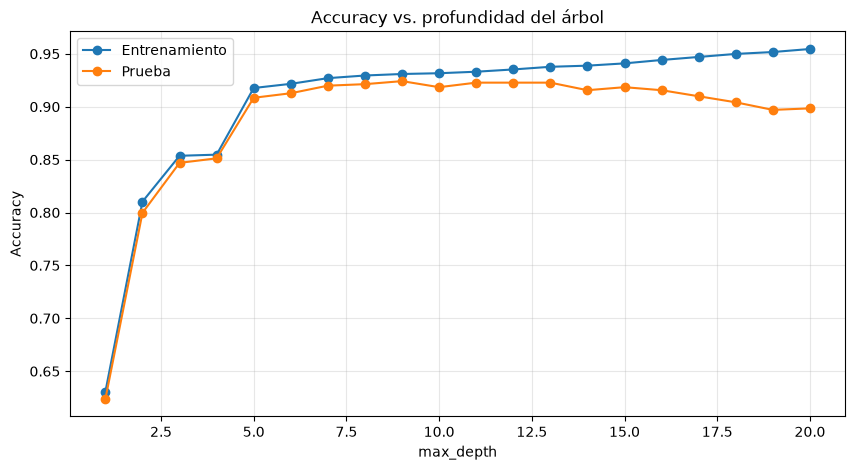

In [71]:
train_scores = []
test_scores = []
profundidades = range(1, 21)

for profundidad in profundidades:
    arbol_temp = DecisionTreeClassifier(
        max_depth=profundidad,
        random_state=42
    )
    arbol_temp.fit(X_train, y_train)
    train_scores.append(arbol_temp.score(X_train, y_train))
    test_scores.append(arbol_temp.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(list(profundidades), train_scores, marker='o', label='Entrenamiento')
plt.plot(list(profundidades), test_scores, marker='o', label='Prueba')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. profundidad del árbol')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10.6. Modelo final con profundidad óptima <a id='dt_final'></a>
[Back to top](#table_of_contents)

Se selecciona automáticamente la profundidad que maximiza el accuracy sobre el conjunto de prueba y se entrena el modelo final con dicho valor.

In [72]:
mejor_profundidad = list(profundidades)[test_scores.index(max(test_scores))]
print("Profundidad con mejor accuracy de prueba:", mejor_profundidad)

arbol_final = DecisionTreeClassifier(
    max_depth=mejor_profundidad,
    random_state=42
)
arbol_final.fit(X_train, y_train)

y_pred = arbol_final.predict(X_test)

print("Accuracy (modelo final):", accuracy_score(y_test, y_pred))

Profundidad con mejor accuracy de prueba: 9
Accuracy (modelo final): 0.9241773962804005


## 10.7. Evaluación del modelo: classification report <a id='dt_report'></a>
[Back to top](#table_of_contents)

In [73]:
print("Reporte de clasificación:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Reporte de clasificación:

              precision    recall  f1-score   support

    Amarillo       0.99      0.93      0.95       227
        Rojo       0.99      0.84      0.91       218
       Verde       0.84      1.00      0.91       254

    accuracy                           0.92       699
   macro avg       0.94      0.92      0.93       699
weighted avg       0.93      0.92      0.92       699



## 10.8. Matriz de confusión <a id='dt_confusion'></a>
[Back to top](#table_of_contents)

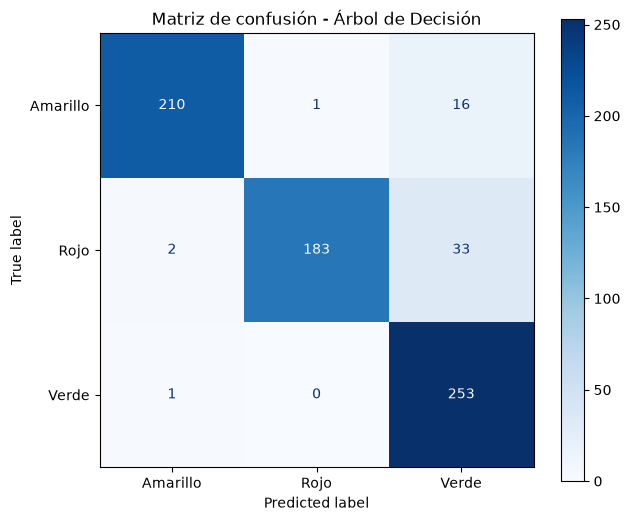

In [74]:
matriz_confusion = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=label_encoder.classes_
)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de confusión - Árbol de Decisión')
plt.show()

## 10.9. Importancia de variables (Feature Importance) <a id='dt_importance'></a>
[Back to top](#table_of_contents)

,Importancia
DQO_mg/L,0.471724
COLI_FEC_NMP_100mL,0.364236
E_COLI_NMP_100mL,0.117728
SST_mg/L,0.026227
OD_PORC,0.016245
DBO_mg/L,0.003841
TOX_V_15_UT,0.000000
TOX_D_48_UT,0.000000


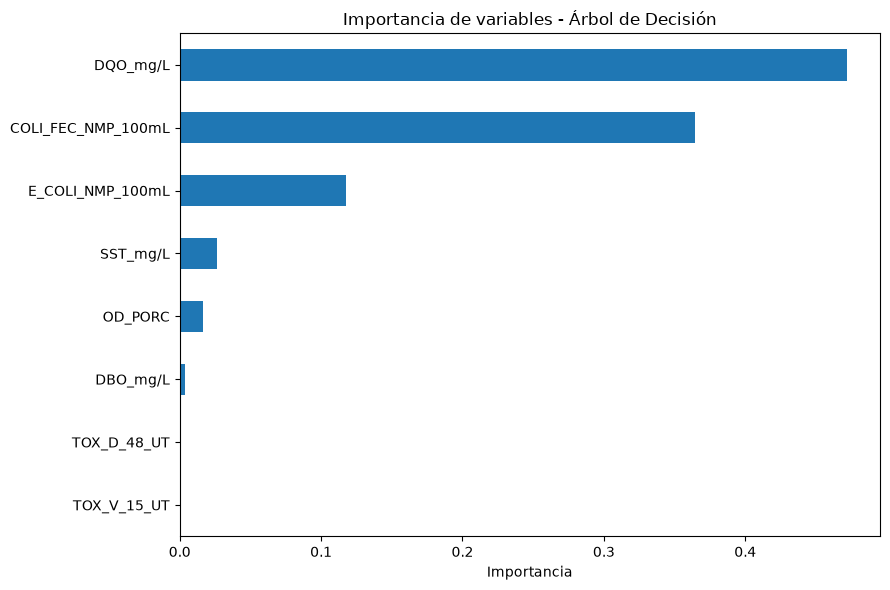

In [75]:
importancias = pd.Series(
    arbol_final.feature_importances_,
    index=variables_seleccionadas
).sort_values(ascending=False)

display(importancias.to_frame(name="Importancia"))

plt.figure(figsize=(9, 6))
importancias.sort_values().plot(kind='barh')
plt.title('Importancia de variables - Árbol de Decisión')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

## 10.10. Visualización del árbol de decisión <a id='dt_plot'></a>
[Back to top](#table_of_contents)

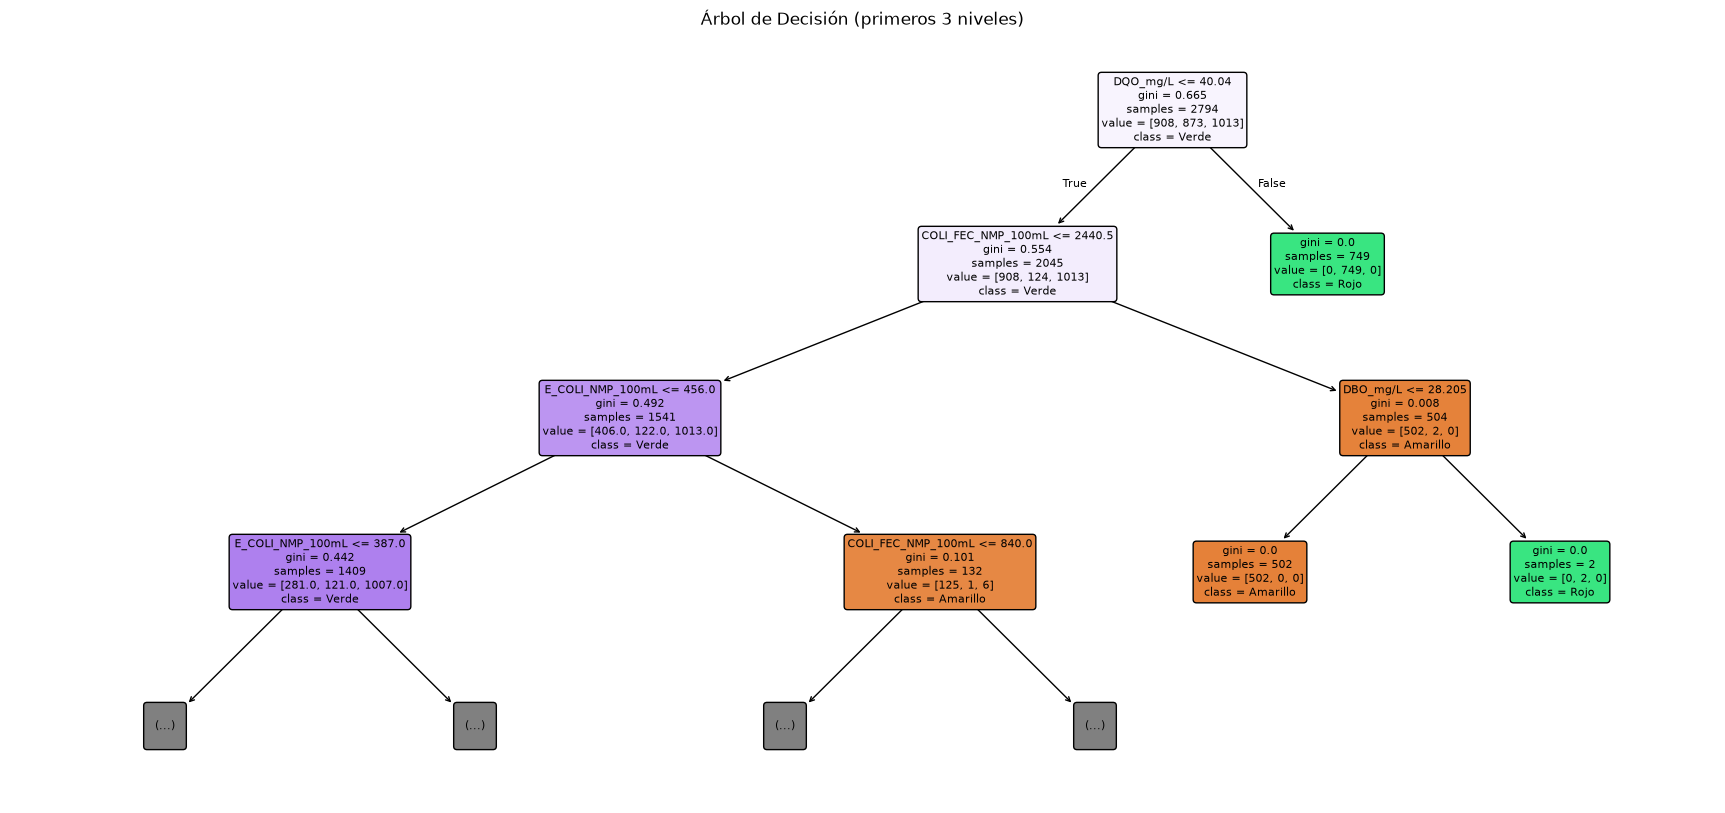

In [76]:
plt.figure(figsize=(22, 10))
plot_tree(
    arbol_final,
    feature_names=variables_seleccionadas,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3  # se limita la profundidad mostrada para mantener la legibilidad
)
plt.title('Árbol de Decisión (primeros 3 niveles)')
plt.show()

## 10.10.2 Visualización del árbol de decisión completo

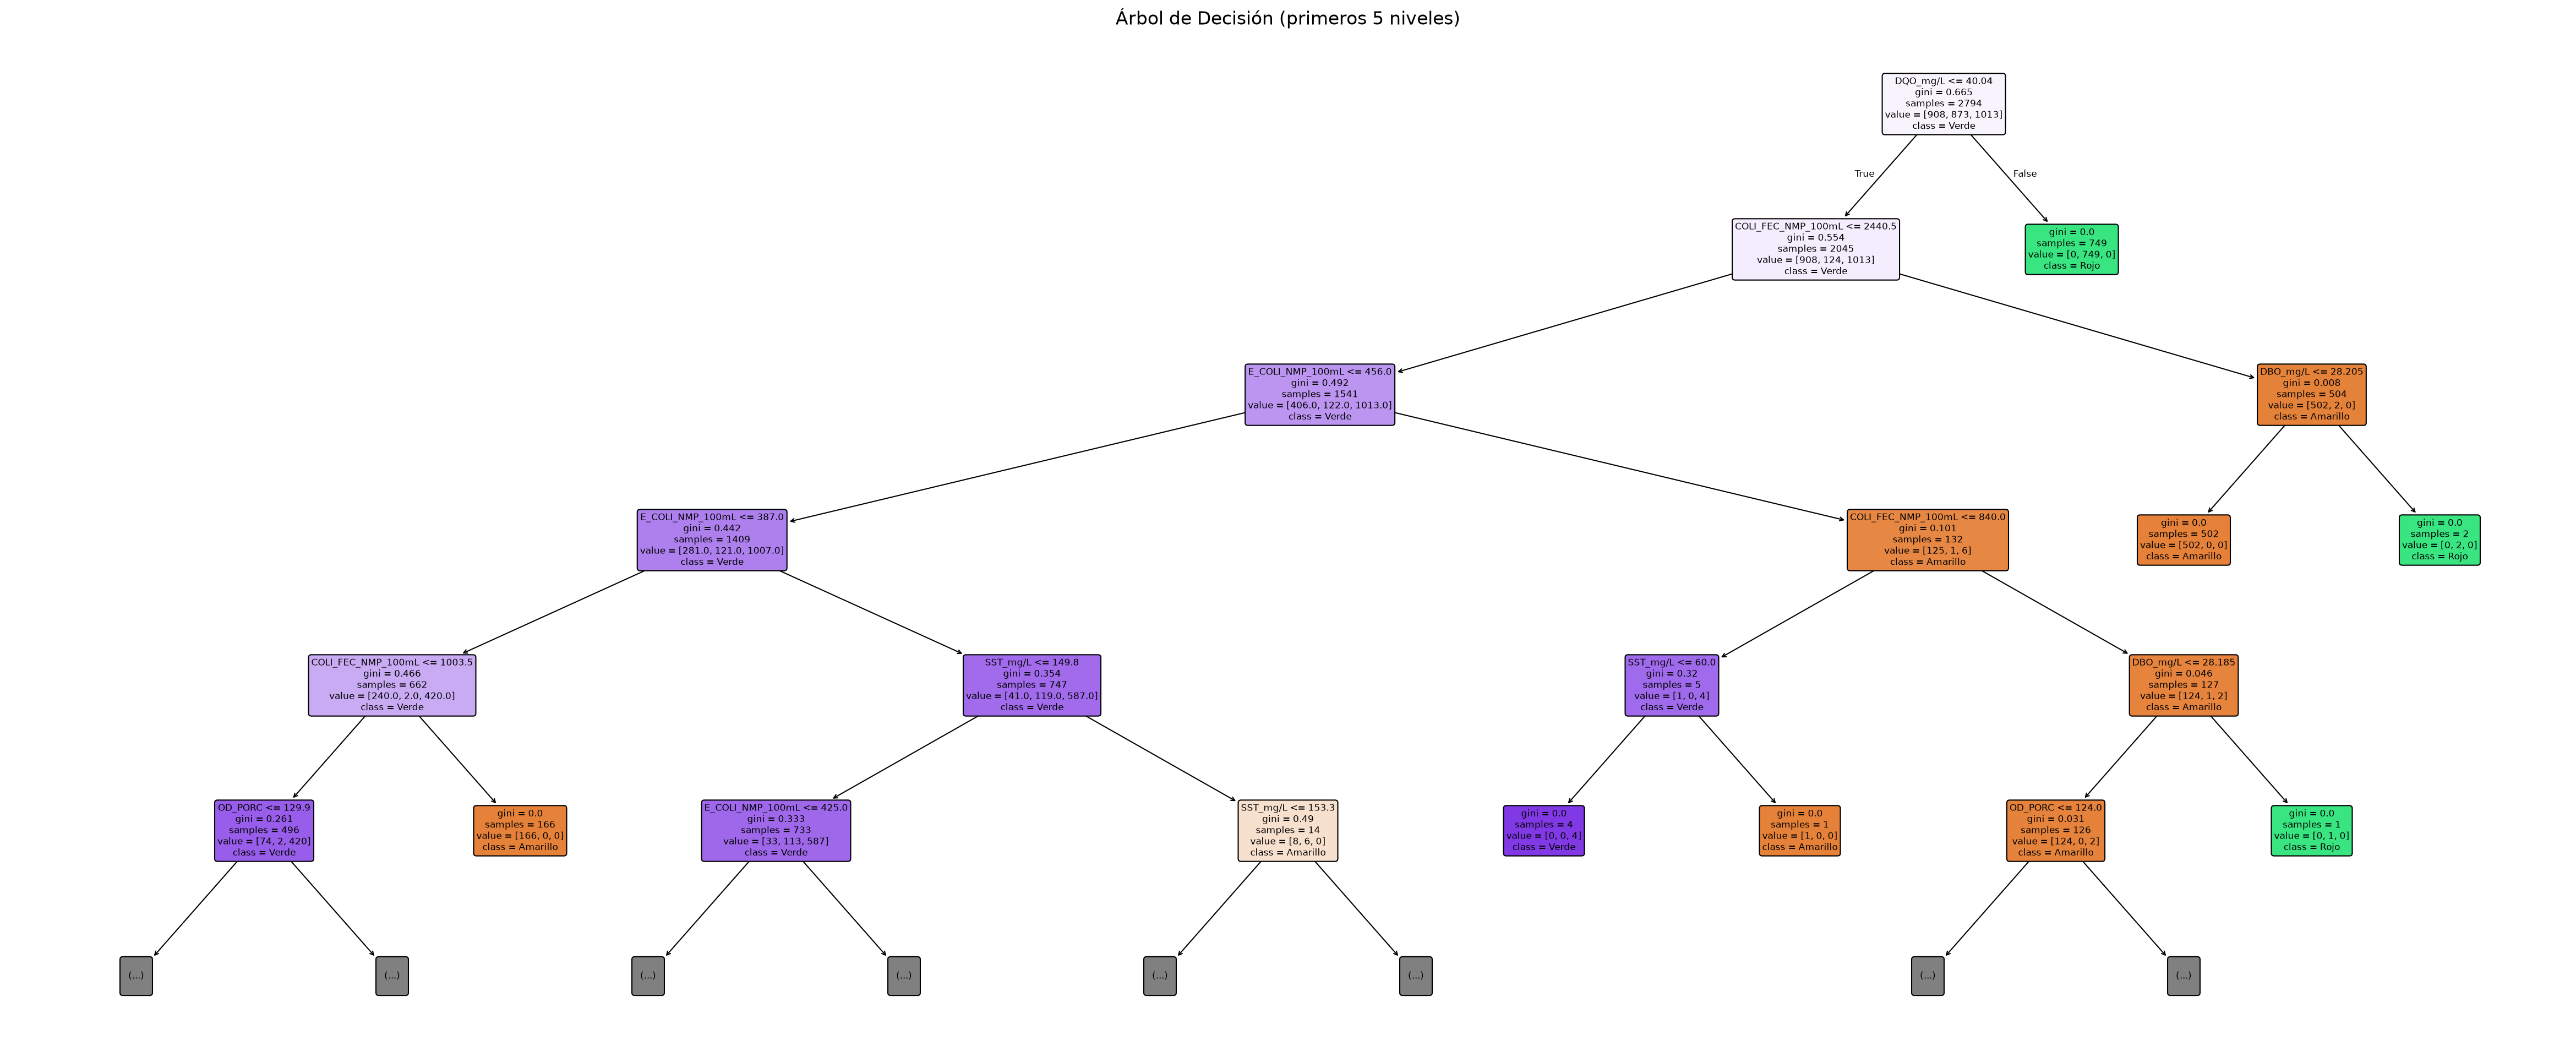

In [77]:
fig, ax = plt.subplots(figsize=(40, 16), dpi=150)  # mucho más ancho que (22,10)

plot_tree(
    arbol_final,
    feature_names=variables_seleccionadas,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=8,       # baja el fontsize si agrandas mucho el ancho
    max_depth=5,
    ax=ax
)
plt.title('Árbol de Decisión (primeros 5 niveles)', fontsize=16)
plt.savefig('arbol_decision_visual.png', dpi=200, bbox_inches='tight')
plt.show()

## 10.11. Conclusiones del Árbol de Decisión <a id='dt_conclusions'></a>
[Back to top](#table_of_contents)

- Un modelo sin podar alcanza un accuracy alto en prueba pero con profundidad muy grande (indicio de sobreajuste); y al limitar `max_depth` mediante la curva de entrenamiento contra la prueba se obtiene un modelo más generalizable con mejor accuracy de prueba que el modelo sin restricciones.
- Las variables con mayor importancia para distinguir el semáforo de calidad del agua son: **DQO** y **Coliformes fecales**, seguidas de **E. coli**; y en conjunto concentran la mayor parte del poder predictivo del árbol, mientras que las variables de toxicidad (`TOX_*`) aportan poco
- La clase `Verde` es la que el modelo predice con mayor recall, mientras que `Rojo` y `Amarillo` presentan más confusión entre sí, lo cual es consistente con que ambas categorías representan niveles intermedios/altos de contaminación con límites de corte cercanos.
- **Limitación:** al no usar una transformación logarítmica ni escalamiento (¡innecesarios para árboles!). El modelo es sensible a valores atípicos extremos en variables como DBO y DQO, lo que puede generar splits muy específicos cerca de las hojas.
- Este modelo junto con sus métricas y su importancia de variables debe compararse con los demás modelos de clasificación desarrollados por el equipo (sección de comparación de modelos) para seleccionar el que se llevará a producción en el despliegue (API + interfaz). 

# 11. Clasificación: Regresión Logística <a id='logreg'></a>
[Back to top](#table_of_contents)

Se entrena un modelo de **Regresión Logística** como modelo lineal de comparación frente al Árbol de Decisión (sección 10) y el Random Forest. Se usan las mismas variables predictoras (`variables_seleccionadas`) y la misma variable objetivo (`SEMAFORO`), con el **mismo split** (`random_state=42`, `stratify`) para que la comparación entre modelos sea justa.

A diferencia del árbol de decision, la regresión logística **sí requiere escalamiento**, ya que optimiza una función de costo basada en gradientes sensible a la magnitud de las variables. Se usa `StandardScaler`, ajustado únicamente sobre `X_train` para evitar fuga de información hacia el conjunto de prueba.

## 11.1. Escalamiento de variables <a id='logreg_scaling'></a>
[Back to top](#table_of_contents)

In [84]:
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 11.2. Entrenamiento del modelo <a id='logreg_train'></a>
[Back to top](#table_of_contents)

Con 3 clases (Verde/Amarillo/Rojo), `LogisticRegression` con el solver `lbfgs` utiliza por defecto una formulación multinomial (softmax), adecuada para clasificación multiclase.

In [85]:
logreg = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)

print("Accuracy (Regresión Logística):", accuracy_score(y_test, y_pred_lr))

Accuracy (Regresión Logística): 0.7553648068669528


## 11.3. Evaluación del modelo: classification report <a id='logreg_report'></a>
[Back to top](#table_of_contents)

In [86]:
print("Reporte de clasificación:\n")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=label_encoder.classes_
    )
)

Reporte de clasificación:

              precision    recall  f1-score   support

    Amarillo       0.74      0.60      0.67       227
        Rojo       0.95      0.82      0.88       218
       Verde       0.65      0.84      0.73       254

    accuracy                           0.76       699
   macro avg       0.78      0.75      0.76       699
weighted avg       0.77      0.76      0.76       699



## 11.4. Matriz de confusión <a id='logreg_confusion'></a>
[Back to top](#table_of_contents)

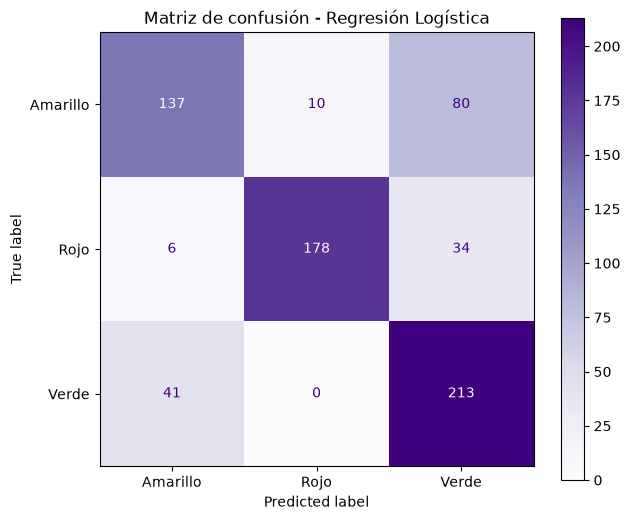

In [87]:
matriz_confusion_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(7, 6))
disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_lr,
    display_labels=label_encoder.classes_
)
disp_lr.plot(ax=ax, cmap='Purples', values_format='d')
plt.title('Matriz de confusión - Regresión Logística')
plt.show()

## 11.5. Coeficientes del modelo <a id='logreg_coef'></a>
[Back to top](#table_of_contents)

A diferencia de `feature_importances_` en el árbol de decision (que no indica direccion), los coeficientes de la regresión logística sí indican si una variable empuja la prediccion hacia una clase específica (signo) y con que fuerza relativa (magnitud), una vez estandarizadas las variables.

,Amarillo,Rojo,Verde
SST_mg/L,1.876896,1.429386,-3.306282
COLI_FEC_NMP_100mL,2.397061,1.028247,-3.425308
E_COLI_NMP_100mL,1.069240,1.127745,-2.196985
DQO_mg/L,-8.055197,10.488139,-2.432942
DBO_mg/L,1.338419,0.636934,-1.975353
TOX_V_15_UT,-0.341516,0.212260,0.129255
TOX_D_48_UT,0.386045,0.012055,-0.398100
OD_PORC,0.163325,-0.056474,-0.106851


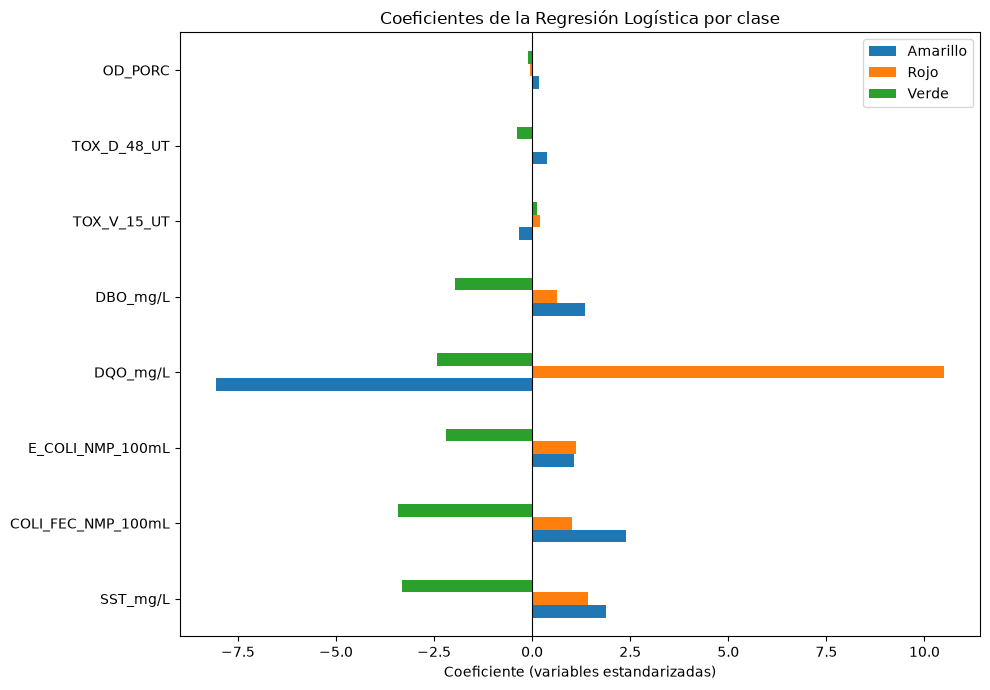

In [88]:
coeficientes = pd.DataFrame(
    logreg.coef_,
    columns=variables_seleccionadas,
    index=label_encoder.classes_
).T

display(coeficientes)

coeficientes.plot(kind='barh', figsize=(10, 7))
plt.title('Coeficientes de la Regresión Logística por clase')
plt.xlabel('Coeficiente (variables estandarizadas)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 11.6. Comparación Árbol de Decisión vs. Regresión Logística <a id='logreg_vs_tree'></a>
[Back to top](#table_of_contents)

In [89]:
comparacion = pd.DataFrame({
    'Modelo': ['Árbol de Decisión (podado)', 'Regresión Logística'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_lr)
    ]
})
display(comparacion)

,Modelo,Accuracy
0,Árbol de Decisión (podado),0.924177
1,Regresión Logística,0.755365


## 11.7. Conclusiones de la Regresión Logística <a id='logreg_conclusions'></a>
[Back to top](#table_of_contents)

- La Regresion Logistica obtiene un accuracy de prueba de **≈0.76**, notablemente inferior al del arbol de Decision podado (**≈0.92**). Esto sugiere que la relación entre las variables fisicoquimicas y el semáforo de calidad **no es puramente lineal**, y que los splits del árbol capturan interacciones y umbrales (por ejemplo, el corte de DQO en 40.04 mg/L) que un modelo lineal no puede representar directamente.
- La clase **`Rojo`** es la mejor identificada por este modelo (precision 0.95, recall 0.82), mientras que **`Amarillo`** es la más difícil de distinguir (recall 0.60), confundiendose principalmente con `Verde`.
- Los coeficientes muestran que **DQO** tiene, por mucho, el mayor peso: valores altos de DQO empujan fuertemente hacia `Rojo` (coeficiente ≈ +10.5) y en contra de `Amarillo` (≈ -8.1), lo cual es consistente con que DQO tambien fue la variable mas importante en el arbol de decision. Ambos modelos coinciden en cuál es la variable mas determinante, aunque discrepan en el resto del orden de importancia.
- **Ventaja de regresion logistica**: aunque su accuracy es menor, su interpretabilidad vía coeficientes es más directa para explicarle a un no técnico *cómo* cada variable afecta la prediccion (dirección y magnitud), algo que el árbol no ofrece de forma tan compacta y simple.
- **Para la sección de comparación de modelos del equipo**: con estos resultados, el Árbol de Decisión (y probablemente el Random Forest, al ser también basado en árboles) son mejores candidatos para el despliegue si la prioridad es el desempeño predictivo; la Regresión Logística queda como referencia interpretativa/baseline.